# GNR638: Assignment-2

In [ ]:
# SECTION 1: Imports

import os
import random
import time
import copy
import warnings
import torch
import gc 
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder

import timm
from fvcore.nn import FlopCountAnalysis, parameter_count_table

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:

# SECTION 2: Global Configuration & Reproducibility

SEED = 42

def set_seed(seed: int = SEED):
    """Fix all random seeds for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# - Experiment hyperparameters -
CONFIG = {
    # Data
  
    "data_root":       "./train_data",  
    "num_classes":     30,
    "image_size":      224,          # standard ImageNet input size
    "train_split":     0.8,         

    # Training 
    "batch_size":      16,
    "num_workers":     2,
    "learning_rate":   1e-3,
    "weight_decay":    1e-4,
    "max_epochs":      30,           
    "few_shot_epochs": 20,           

    # Few-shot data fractions 
    "few_shot_fractions": [1.0, 0.20, 0.05],

    # Corruption params 
    "gaussian_sigmas": [0.05, 0.1, 0.2],

    "seed":            SEED,
    "device":          "cuda" if torch.cuda.is_available() else "cpu",
    "output_dir":      "./output",
}

# Create output directory
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(f"[Config] Device : {CONFIG['device']}")
print(f"[Config] Output : {CONFIG['output_dir']}")

[Config] Device : cuda
[Config] Output : ./output


In [ ]:

# SECTION 3: Dataset & DataLoader
# ImageNet normalisation statistics 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(image_size: int = 224, augment: bool = True):
 
    # Validation / test: deterministic resize + crop + normalize
    val_transform = transforms.Compose([
        transforms.Resize(int(image_size * 1.14)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    if not augment:
        return val_transform, val_transform

    # Training: light augmentation 
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2,
                               saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return train_transform, val_transform


def build_dataloaders(
    data_root: str,
    image_size: int  = 224,
    batch_size: int  = 32,
    train_split: float = 0.8,
    num_workers: int = 2,
    fraction: float  = 1.0,
    seed: int        = SEED,
):
   
    train_tf, val_tf = get_transforms(image_size, augment=True)

    # Load full dataset with train transforms (val images re-wrapped below)
    full_dataset = ImageFolder(root=data_root)
    class_names  = full_dataset.classes
    n_total      = len(full_dataset)

    #  Reproducible train/val split 
    rng     = np.random.default_rng(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    n_train    = int(n_total * train_split)
    train_idx  = indices[:n_train].tolist()
    val_idx    = indices[n_train:].tolist()

    if fraction < 1.0:
        k = max(1, int(len(train_idx) * fraction))
        rng2      = np.random.default_rng(seed)      # same seed → same subset
        train_idx = rng2.choice(train_idx, size=k, replace=False).tolist()


    # We use a simple lambda-based dataset wrapper to apply different transforms
    class _TransformSubset(torch.utils.data.Dataset):
        def __init__(self, base_ds, idx, transform):
            self.base      = base_ds
            self.idx       = idx
            self.transform = transform
        def __len__(self):
            return len(self.idx)
        def __getitem__(self, i):
            img, label = self.base[self.idx[i]]
            return self.transform(img), label

    raw_dataset = ImageFolder(root=data_root, transform=None)

    train_ds = _TransformSubset(raw_dataset, train_idx, train_tf)
    val_ds   = _TransformSubset(raw_dataset, val_idx,   val_tf)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    print(f"[Dataset] Classes      : {len(class_names)}")
    print(f"[Dataset] Total images : {n_total}")
    print(f"[Dataset] Train        : {len(train_ds)}  (fraction={fraction:.0%})")
    print(f"[Dataset] Val          : {len(val_ds)}")

    return train_loader, val_loader, class_names

In [ ]:

# SECTION 4: Model Loading via timm
#   ResNet50     – classic residual network (skip connections)
#   EfficientNet-B0 – compound-scaled lightweight CNN
#   ConvNeXt-Tiny  – modernised pure-CNN inspired by ViT training recipes
MODEL_NAMES = {
    "resnet50":        "resnet50",
    "efficientnet_b0": "efficientnet_b0",
    "convnext_tiny":   "convnext_tiny",
}


def load_model(
    model_key: str,
    num_classes: int = 30,
    pretrained: bool = True,
    freeze_backbone: bool = False,
) -> nn.Module:
    """
    Load a timm pre-trained CNN, replacing the head for the target task.

    Args:
        model_key:        Key in MODEL_NAMES dict.
        num_classes:      Number of target classes (AID = 30).
        pretrained:       Load ImageNet weights when True.
        freeze_backbone:  Freeze all layers except the final classifier.

    Returns:
        model (nn.Module) with modified classification head.
    """
    timm_name = MODEL_NAMES[model_key]

    # timm creates the model with the correct pretrained weights and
    # automatically replaces the head for num_classes
    model = timm.create_model(
        timm_name,
        pretrained=pretrained,
        num_classes=num_classes,
    )

    if freeze_backbone:
        # Freeze all parameters
        for param in model.parameters():
            param.requires_grad = False
        # timm exposes the head as model.get_classifier()
        for param in model.get_classifier().parameters():
            param.requires_grad = True

    total    = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[Model] {model_key:20s} | total params: {total:,} | "
          f"trainable: {trainable:,} | frozen: {freeze_backbone}")

    return model

In [ ]:

# SECTION 5: Efficiency Metrics (Parameters, MACs, FLOPs)
def print_efficiency_metrics(model: nn.Module, model_name: str,
                              image_size: int = 224, device: str = "cpu"):
    model = model.to(device)
    model.eval()

    dummy_input = torch.zeros(1, 3, image_size, image_size, device=device)

    #  Parameter counts
    total_params    = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters()
                           if p.requires_grad)
    frozen_params   = total_params - trainable_params

    #  MACs / FLOPs via fvcore 
    flop_analyzer = FlopCountAnalysis(model, dummy_input)
    flop_analyzer.unsupported_ops_warnings(False)
    flop_analyzer.uncalled_modules_warnings(False)

    macs  = flop_analyzer.total()         
    flops = macs * 2                      
    print("\n" + "=" * 60)
    print(f"  Efficiency Metrics: {model_name}")
    print("=" * 60)
    print(f"  Total parameters     : {total_params:>15,}")
    print(f"  Trainable parameters : {trainable_params:>15,}")
    print(f"  Frozen parameters    : {frozen_params:>15,}")
    print(f"  MACs                 : {macs:>15,}  ({macs/1e9:.3f} G)")
    print(f"  FLOPs (≈2×MACs)      : {flops:>15,}  ({flops/1e9:.3f} G)")
    print("=" * 60 + "\n")

    return {
        "model":             model_name,
        "total_params":      total_params,
        "trainable_params":  trainable_params,
        "frozen_params":     frozen_params,
        "MACs":              macs,
        "FLOPs":             flops,
    }

In [ ]:

# SECTION 6: Training & Validation Loop
class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = self.avg = self.sum = self.count = 0.0
    def update(self, val, n=1):
        self.val    = val
        self.sum   += val * n
        self.count += n
        self.avg    = self.sum / self.count


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_meter = AverageMeter()
    acc_meter  = AverageMeter()

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds   = outputs.argmax(dim=1)
        correct = (preds == labels).sum().item()
        loss_meter.update(loss.item(), images.size(0))
        acc_meter.update(correct / images.size(0), images.size(0))

    return loss_meter.avg, acc_meter.avg * 100.0


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Evaluate on validation set, return (avg_loss, accuracy)."""
    model.eval()
    loss_meter = AverageMeter()
    acc_meter  = AverageMeter()

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        preds   = outputs.argmax(dim=1)
        correct = (preds == labels).sum().item()
        loss_meter.update(loss.item(), images.size(0))
        acc_meter.update(correct / images.size(0), images.size(0))

    return loss_meter.avg, acc_meter.avg * 100.0


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    num_epochs:   int   = 30,
    lr:           float = 1e-3,
    weight_decay: float = 1e-4,
    device:       str   = "cpu",
    model_name:   str   = "model",
    save_best:    bool  = True,
    output_dir:   str   = ".",
):
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
    }
    best_val_acc   = 0.0
    best_state     = None

    print(f"\n{'─'*60}")
    print(f"  Training: {model_name}  |  epochs={num_epochs}  |  device={device}")
    print(f"{'─'*60}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = validate(
            model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        elapsed = time.time() - t0
        print(f"  Epoch [{epoch:02d}/{num_epochs}] "
              f"| train loss: {tr_loss:.4f}  acc: {tr_acc:.2f}% "
              f"| val loss: {va_loss:.4f}  acc: {va_acc:.2f}% "
              f"| {elapsed:.1f}s")

        # Save best checkpoint 
        if save_best and va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = copy.deepcopy(model.state_dict())
            ckpt_path    = os.path.join(output_dir, f"{model_name}_best.pth")
            torch.save(best_state, ckpt_path)

    print(f"\n  ✓ Best Val Acc ({model_name}): {best_val_acc:.2f}%")

    # Restore best weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc

In [ ]:

# SECTION 7: Visualisation Utilities


def plot_training_curves(history: dict, model_name: str, save_dir: str = "."):
    epochs = range(1, len(history["train_acc"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    axes[0].plot(epochs, history["train_acc"], label="Train")
    axes[0].plot(epochs, history["val_acc"],   label="Val")
    axes[0].set_title(f"{model_name} – Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
    axes[0].legend(); axes[0].grid(True)

    # Loss
    axes[1].plot(epochs, history["train_loss"], label="Train")
    axes[1].plot(epochs, history["val_loss"],   label="Val")
    axes[1].set_title(f"{model_name} – Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_curves.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Saved → {save_path}")


@torch.no_grad()
def plot_confusion_matrix(model, loader, class_names, model_name,
                           device="cpu", save_dir="."):
    
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        preds  = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix – {model_name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_confusion.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Saved → {save_path}")


@torch.no_grad()
def extract_features(model: nn.Module, loader: DataLoader,
                     device: str = "cpu"):
    
    model.eval()
    feats, lbls = [], []

    for images, labels in loader:
        images = images.to(device)
        # timm models expose forward_features() → feature tensor (pre-head)
        f = model.forward_features(images)
        # Global-average-pool if spatial dims remain
        if f.dim() == 4:
            f = f.mean(dim=[2, 3])
        elif f.dim() == 3:         
            f = f.mean(dim=1)
        feats.append(f.cpu().numpy())
        lbls.append(labels.numpy())

    return np.vstack(feats), np.concatenate(lbls)


def plot_pca_embedding(features: np.ndarray, labels: np.ndarray,
                       class_names: list, model_name: str,
                       method: str = "PCA", save_dir: str = "."):
  
    if method.upper() == "TSNE":
        reducer  = TSNE(n_components=2, random_state=SEED, perplexity=30,
                        n_iter=1000)
        coords   = reducer.fit_transform(features)
        subtitle = "t-SNE"
    else:
        reducer  = PCA(n_components=2, random_state=SEED)
        coords   = reducer.fit_transform(features)
        subtitle = f"PCA (var explained: {reducer.explained_variance_ratio_.sum():.1%})"

    palette = plt.cm.get_cmap("tab20", len(class_names))
    fig, ax = plt.subplots(figsize=(10, 8))
    for cls_idx, cls_name in enumerate(class_names):
        mask = labels == cls_idx
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=palette(cls_idx), label=cls_name,
                   s=10, alpha=0.7)
    ax.set_title(f"{model_name} – {subtitle}")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left",
              fontsize=6, markerscale=2)
    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{model_name}_{method.lower()}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] Saved → {save_path}")

In [ ]:

# SECTION 8: Corruption Utilities 

def add_gaussian_noise(tensor: torch.Tensor, sigma: float) -> torch.Tensor:
    """Add Gaussian noise with std=sigma to a (B, C, H, W) tensor."""
    return torch.clamp(tensor + torch.randn_like(tensor) * sigma, 0.0, 1.0)


def motion_blur_kernel(size: int = 15) -> torch.Tensor:
    """Create a horizontal motion-blur kernel of given size."""
    kernel = torch.zeros(size, size)
    kernel[size // 2, :] = 1.0 / size
    return kernel


def apply_motion_blur(tensor: torch.Tensor, kernel_size: int = 15) -> torch.Tensor:
    """Apply motion blur using a 1-D horizontal convolution."""
    import torch.nn.functional as F
    B, C, H, W = tensor.shape
    k   = motion_blur_kernel(kernel_size).to(tensor.device)
    # Expand kernel: (out_ch, in_ch/groups, kH, kW)
    k   = k.unsqueeze(0).unsqueeze(0).repeat(C, 1, 1, 1)
    pad = kernel_size // 2
    blurred = F.conv2d(tensor, k, padding=(pad, pad), groups=C)
    return torch.clamp(blurred, 0.0, 1.0)


def brightness_shift(tensor: torch.Tensor, delta: float = 0.2) -> torch.Tensor:
    """Uniformly shift pixel brightness by delta."""
    return torch.clamp(tensor + delta, 0.0, 1.0)


def get_corrupted_loader(
    data_root: str,
    corruption: str,
    severity,              # float (sigma) for noise; 
    batch_size: int = 32,
    num_workers: int = 2,
    seed: int = SEED,
):
    # Build tensor transform chain with corruption injected
    base_tf = [
        transforms.Resize(int(image_size * 1.14)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
    ]

    if corruption == "gaussian":
        corrupt_tf = transforms.Lambda(
            lambda t: add_gaussian_noise(t.unsqueeze(0), severity).squeeze(0))
    elif corruption == "motion_blur":
        corrupt_tf = transforms.Lambda(
            lambda t: apply_motion_blur(t.unsqueeze(0)).squeeze(0))
    elif corruption == "brightness":
        delta = severity if isinstance(severity, float) else 0.2
        corrupt_tf = transforms.Lambda(
            lambda t: brightness_shift(t.unsqueeze(0), delta).squeeze(0))
    else:
        raise ValueError(f"Unknown corruption: {corruption}")

    full_tf = transforms.Compose(
        base_tf + [corrupt_tf,
                   transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)]
    )

    dataset = ImageFolder(root=data_root, transform=full_tf)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=True)
    return loader

In [ ]:
# SECTION 9: Gradient Norm Utility  (Section 4.2)

def compute_gradient_norms(model: nn.Module) -> dict:
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.data.norm(2).item()
    return norms

In [ ]:

# SECTION 10: Layer-Wise Feature Probing  (Section 4.5)


def register_feature_hook(model: nn.Module, layer_name: str):
    cache = {}
    def hook_fn(module, input, output):
        cache['features'] = output.detach()
    parts  = layer_name.split('.')
    module = model
    for p in parts:
        module = getattr(module, p)

    module.register_forward_hook(hook_fn)
    return cache


def get_probe_layers(model_key: str):
    """
    Return (early, middle, final) layer names for each architecture.
    """
    probe_map = {
        "resnet50": {
            "early":  "layer1",
            "middle": "layer3",
            "final":  "layer4",
        },
        "efficientnet_b0": {
            "early":  "blocks.1",
            "middle": "blocks.4",
            "final":  "blocks.6",
        },
        "convnext_tiny": {
            "early":  "stages.0",
            "middle": "stages.2",
            "final":  "stages.3",
        },
    }
    return probe_map.get(model_key, {})

In [ ]:

# SECTION 11: Main Experiment Runner


def run_linear_probe(model_key: str, train_loader, val_loader, class_names,
                     cfg: dict):
  
    print(f"\n{'='*60}")
    print(f"  SCENARIO 4.1 – Linear Probe: {model_key}")
    print(f"{'='*60}")

    model = load_model(model_key, num_classes=cfg["num_classes"],
                       pretrained=True, freeze_backbone=True)

    metrics = print_efficiency_metrics(
        model, model_key, cfg["image_size"], cfg["device"])

    history, best_acc = train_model(
        model, train_loader, val_loader,
        num_epochs=cfg["max_epochs"],
        lr=cfg["learning_rate"],
        weight_decay=cfg["weight_decay"],
        device=cfg["device"],
        model_name=f"{model_key}_linear_probe",
        save_best=True,
        output_dir=cfg["output_dir"],
    )

    #  Plots 
    plot_training_curves(history, f"{model_key}_linear_probe", cfg["output_dir"])
    plot_confusion_matrix(model, val_loader, class_names,
                          f"{model_key}_linear_probe",
                          cfg["device"], cfg["output_dir"])

    feats, labels = extract_features(model, val_loader, cfg["device"])
    plot_pca_embedding(feats, labels, class_names,
                       f"{model_key}_linear_probe",
                       method="PCA", save_dir=cfg["output_dir"])

    return history, best_acc, metrics


def run_few_shot(model_key: str, val_loader, class_names, cfg: dict):
    print(f"\n{'='*60}")
    print(f"  SCENARIO 4.3 – Few-Shot: {model_key}")
    print(f"{'='*60}")

    results = {}
    for frac in cfg["few_shot_fractions"]:
        epochs = cfg["max_epochs"] if frac == 1.0 else cfg["few_shot_epochs"]

        tr_loader, _, _ = build_dataloaders(
            cfg["data_root"],
            image_size=cfg["image_size"],
            batch_size=cfg["batch_size"],
            train_split=cfg["train_split"],
            num_workers=cfg["num_workers"],
            fraction=frac,
            seed=cfg["seed"],
        )

        model = load_model(model_key, num_classes=cfg["num_classes"],
                           pretrained=True, freeze_backbone=False)

        history, best_acc = train_model(
            model, tr_loader, val_loader,
            num_epochs=epochs,
            lr=cfg["learning_rate"],
            weight_decay=cfg["weight_decay"],
            device=cfg["device"],
            model_name=f"{model_key}_fewshot_{int(frac*100)}pct",
            save_best=True,
            output_dir=cfg["output_dir"],
        )
        results[frac] = {"history": history, "best_acc": best_acc}
        print(f"  [{model_key}] frac={frac:.0%}  best_val_acc={best_acc:.2f}%")

    #  Relative performance drop 
    acc100 = results[1.00]["best_acc"]
    acc5   = results[0.05]["best_acc"]
    delta  = (acc100 - acc5) / acc100
    print(f"\n  Relative performance drop Δ = {delta:.3f}  "
          f"({acc100:.2f}% → {acc5:.2f}%)")

    return results


@torch.no_grad()
def run_corruption_eval(model: nn.Module, model_key: str, clean_acc: float,
                        cfg: dict):
    """
    Scenario 4.4 – Corruption Robustness Evaluation.
    Evaluates pre-trained (fine-tuned) model under Gaussian noise,
    motion blur, and brightness shift.
    """
    print(f"\n{'='*60}")
    print(f"  SCENARIO 4.4 – Corruption Robustness: {model_key}")
    print(f"{'='*60}")

    model  = model.to(cfg["device"])
    model.eval()
    criterion = nn.CrossEntropyLoss()
    rows = []

    #  Gaussian noise at multiple severities 
    for sigma in cfg["gaussian_sigmas"]:
        loader  = get_corrupted_loader(
            cfg["data_root"], "gaussian", sigma,
            cfg["image_size"], cfg["batch_size"], cfg["num_workers"])
        _, acc  = validate(model, loader, criterion, cfg["device"])
        ce      = 1.0 - acc / 100.0
        rel_rob = acc / clean_acc
        rows.append({"corruption": f"Gaussian σ={sigma}",
                     "acc": acc, "CE": ce, "RelRob": rel_rob})
        print(f"  Gaussian σ={sigma:.2f}  acc={acc:.2f}%  "
              f"CE={ce:.4f}  RelRob={rel_rob:.4f}")

    #  Motion blur 
    loader  = get_corrupted_loader(
        cfg["data_root"], "motion_blur", None,
        cfg["image_size"], cfg["batch_size"], cfg["num_workers"])
    _, acc  = validate(model, loader, criterion, cfg["device"])
    ce      = 1.0 - acc / 100.0
    rel_rob = acc / clean_acc
    rows.append({"corruption": "Motion Blur",
                 "acc": acc, "CE": ce, "RelRob": rel_rob})
    print(f"  Motion Blur  acc={acc:.2f}%  CE={ce:.4f}  RelRob={rel_rob:.4f}")

    #  Brightness shift 
    loader  = get_corrupted_loader(
        cfg["data_root"], "brightness", 0.2,
        cfg["image_size"], cfg["batch_size"], cfg["num_workers"])
    _, acc  = validate(model, loader, criterion, cfg["device"])
    ce      = 1.0 - acc / 100.0
    rel_rob = acc / clean_acc
    rows.append({"corruption": "Brightness +0.2",
                 "acc": acc, "CE": ce, "RelRob": rel_rob})
    print(f"  Brightness   acc={acc:.2f}%  CE={ce:.4f}  RelRob={rel_rob:.4f}")

    return rows


############################################################
  GNR638 Assignment-2 | Starting experiments
  Device: cuda
############################################################

[Dataset] Classes      : 30
[Dataset] Total images : 6993
[Dataset] Train        : 5594  (fraction=100%)
[Dataset] Val          : 1399

############################################################
  Model: RESNET50
############################################################

  SCENARIO 4.1 – Linear Probe: resnet50


[Model] resnet50             | total params: 23,569,502 | trainable: 61,470 | frozen: True

  Efficiency Metrics: resnet50
  Total parameters     :      23,569,502
  Trainable parameters :          61,470
  Frozen parameters    :      23,508,032
  MACs                 :   4,109,526,016  (4.110 G)
  FLOPs (≈2×MACs)      :   8,219,052,032  (8.219 G)


────────────────────────────────────────────────────────────
  Training: resnet50_linear_probe  |  epochs=30  |  device=cuda
────────────────────────────────────────────────────────────
  Epoch [01/30] | train loss: 2.5455  acc: 50.82% | val loss: 2.0102  acc: 70.76% | 26.6s
  Epoch [02/30] | train loss: 1.8070  acc: 70.51% | val loss: 1.6424  acc: 78.20% | 27.5s
  Epoch [03/30] | train loss: 1.5616  acc: 76.90% | val loss: 1.4897  acc: 78.56% | 27.7s
  Epoch [04/30] | train loss: 1.4383  acc: 79.10% | val loss: 1.4271  acc: 79.13% | 27.3s
  Epoch [05/30] | train loss: 1.3804  acc: 79.75% | val loss: 1.3297  acc: 82.63% | 28.3s
  Epoch [06/

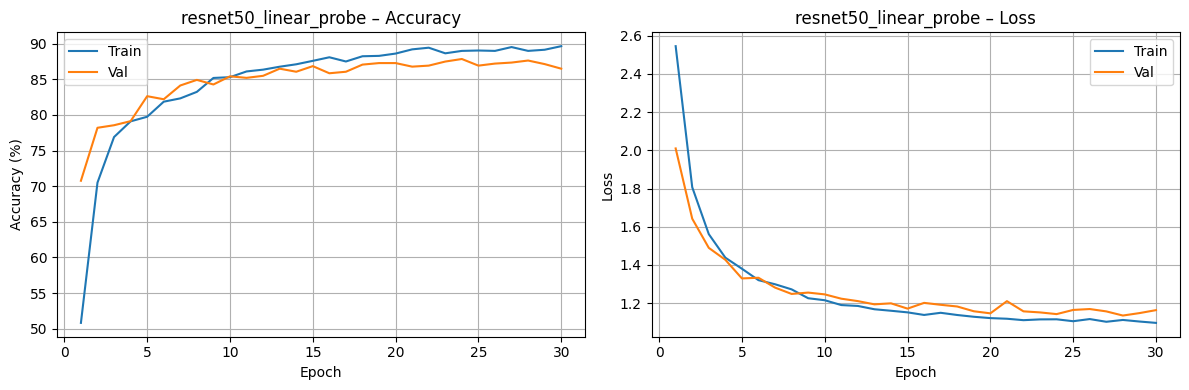

[Plot] Saved → ./output/resnet50_linear_probe_curves.png


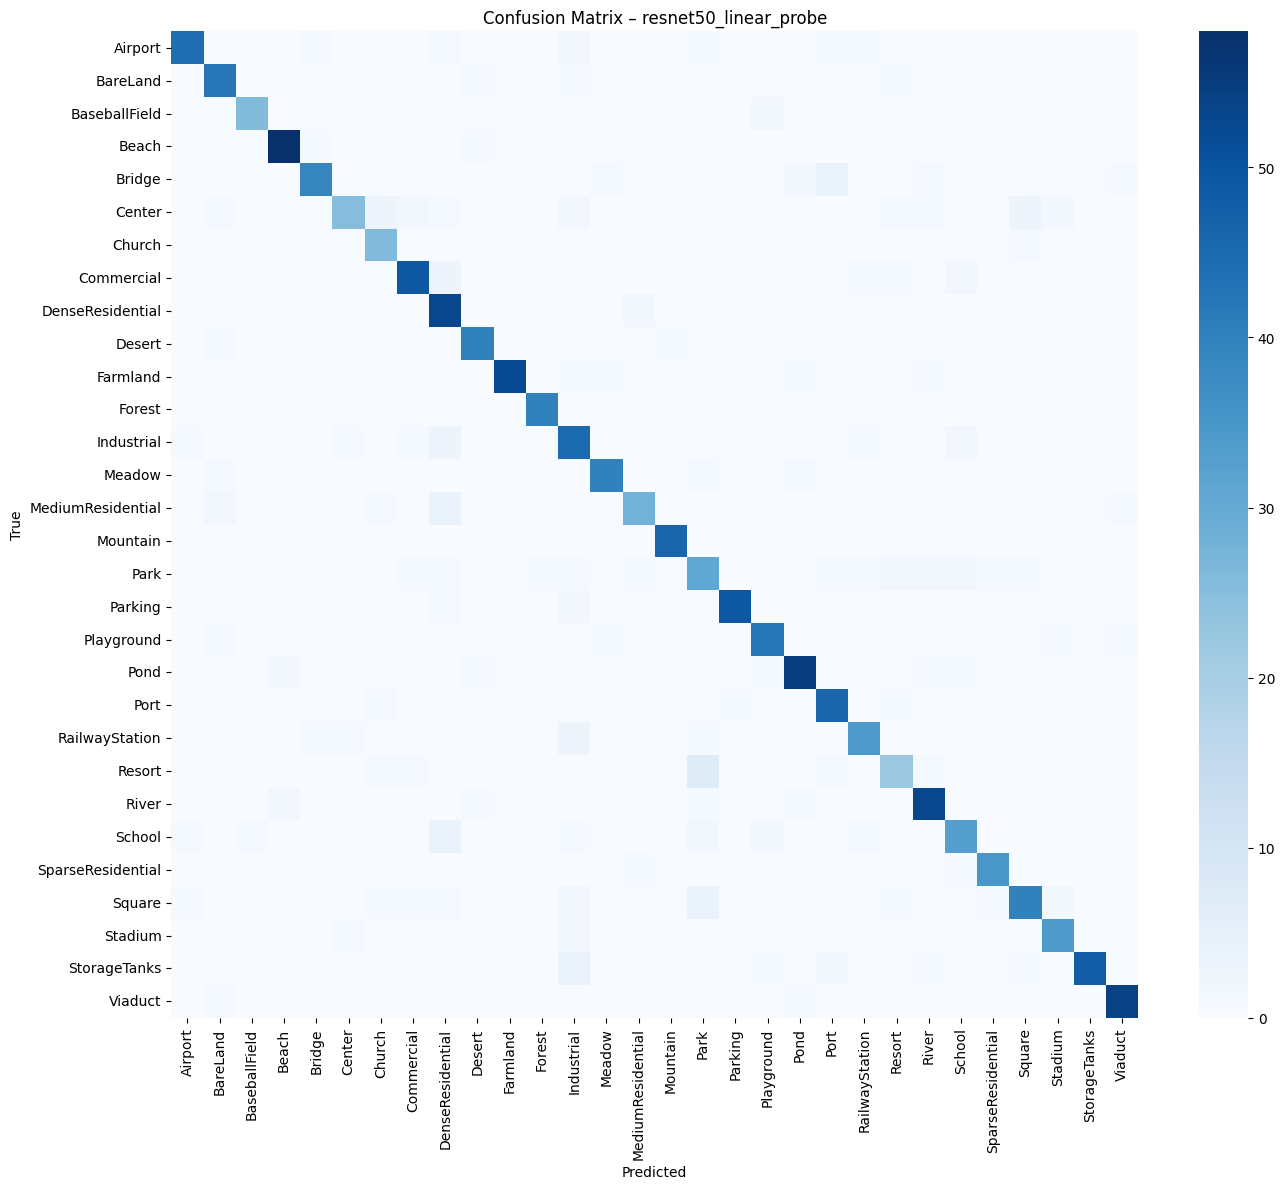

[Plot] Saved → ./output/resnet50_linear_probe_confusion.png


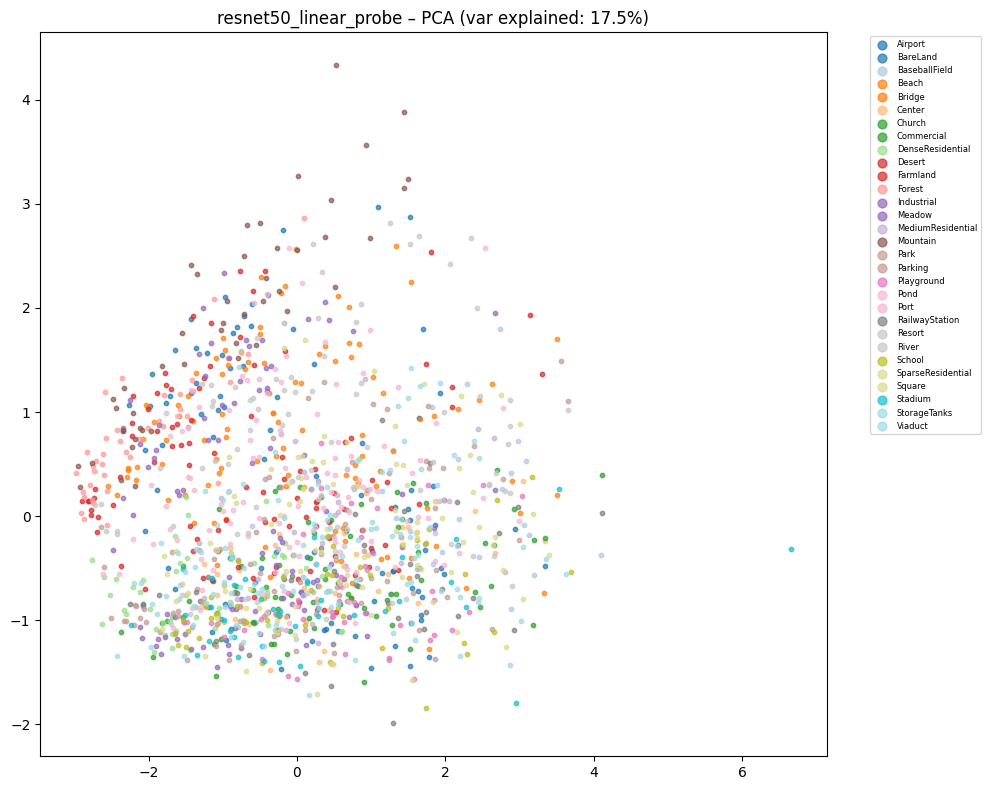

[Plot] Saved → ./output/resnet50_linear_probe_pca.png

  SCENARIO 4.2 – Full Fine-Tuning: resnet50
[Model] resnet50             | total params: 23,569,502 | trainable: 23,569,502 | frozen: False

  Efficiency Metrics: resnet50_full_ft
  Total parameters     :      23,569,502
  Trainable parameters :      23,569,502
  Frozen parameters    :               0
  MACs                 :   4,109,526,016  (4.110 G)
  FLOPs (≈2×MACs)      :   8,219,052,032  (8.219 G)


────────────────────────────────────────────────────────────
  Training: resnet50_full_ft  |  epochs=30  |  device=cuda
────────────────────────────────────────────────────────────
  Epoch [01/30] | train loss: 2.9515  acc: 29.39% | val loss: 1.9882  acc: 65.69% | 43.3s
  Epoch [02/30] | train loss: 1.6144  acc: 72.80% | val loss: 1.1240  acc: 86.63% | 44.0s
  Epoch [03/30] | train loss: 1.1803  acc: 82.86% | val loss: 0.9614  acc: 90.64% | 44.2s
  Epoch [04/30] | train loss: 1.0112  acc: 88.59% | val loss: 0.8856  acc: 93.14% | 4

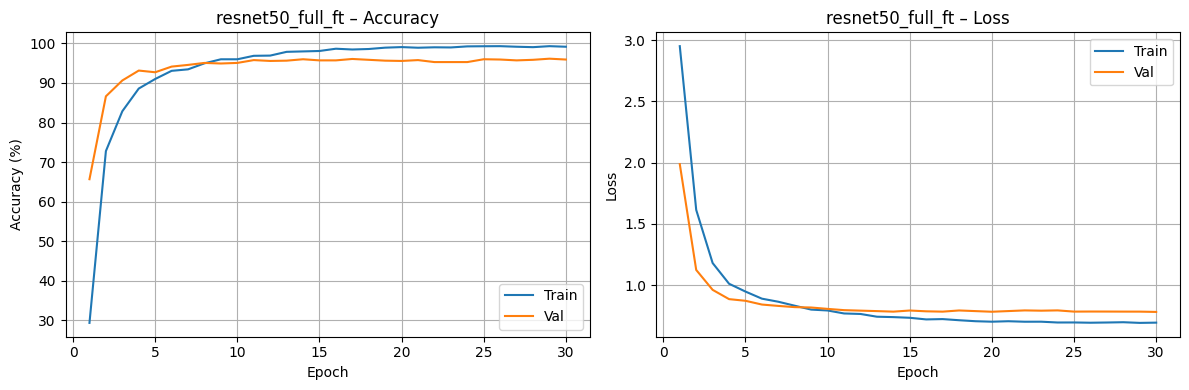

[Plot] Saved → ./output/resnet50_full_ft_curves.png

  SCENARIO 4.3 – Few-Shot: resnet50
[Dataset] Classes      : 30
[Dataset] Total images : 6993
[Dataset] Train        : 5594  (fraction=100%)
[Dataset] Val          : 1399
[Model] resnet50             | total params: 23,569,502 | trainable: 23,569,502 | frozen: False

────────────────────────────────────────────────────────────
  Training: resnet50_fewshot_100pct  |  epochs=30  |  device=cuda
────────────────────────────────────────────────────────────
  Epoch [01/30] | train loss: 1.6048  acc: 68.80% | val loss: 1.0885  acc: 86.99% | 53.1s
  Epoch [02/30] | train loss: 1.0359  acc: 87.63% | val loss: 0.9771  acc: 90.35% | 51.9s
  Epoch [03/30] | train loss: 0.9421  acc: 90.88% | val loss: 0.9129  acc: 92.42% | 52.1s
  Epoch [04/30] | train loss: 0.9109  acc: 92.59% | val loss: 0.9839  acc: 89.49% | 52.2s
  Epoch [05/30] | train loss: 0.9088  acc: 92.69% | val loss: 0.9680  acc: 90.92% | 51.9s
  Epoch [06/30] | train loss: 0.9041  acc

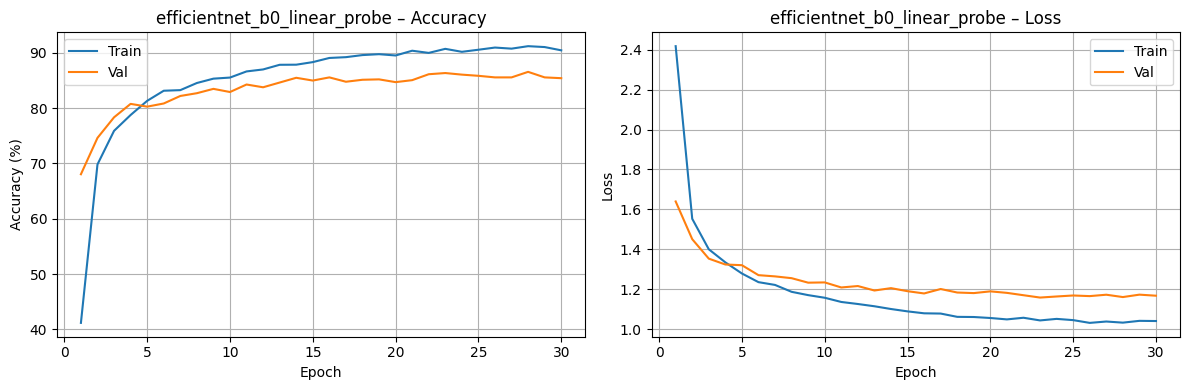

[Plot] Saved → ./output/efficientnet_b0_linear_probe_curves.png


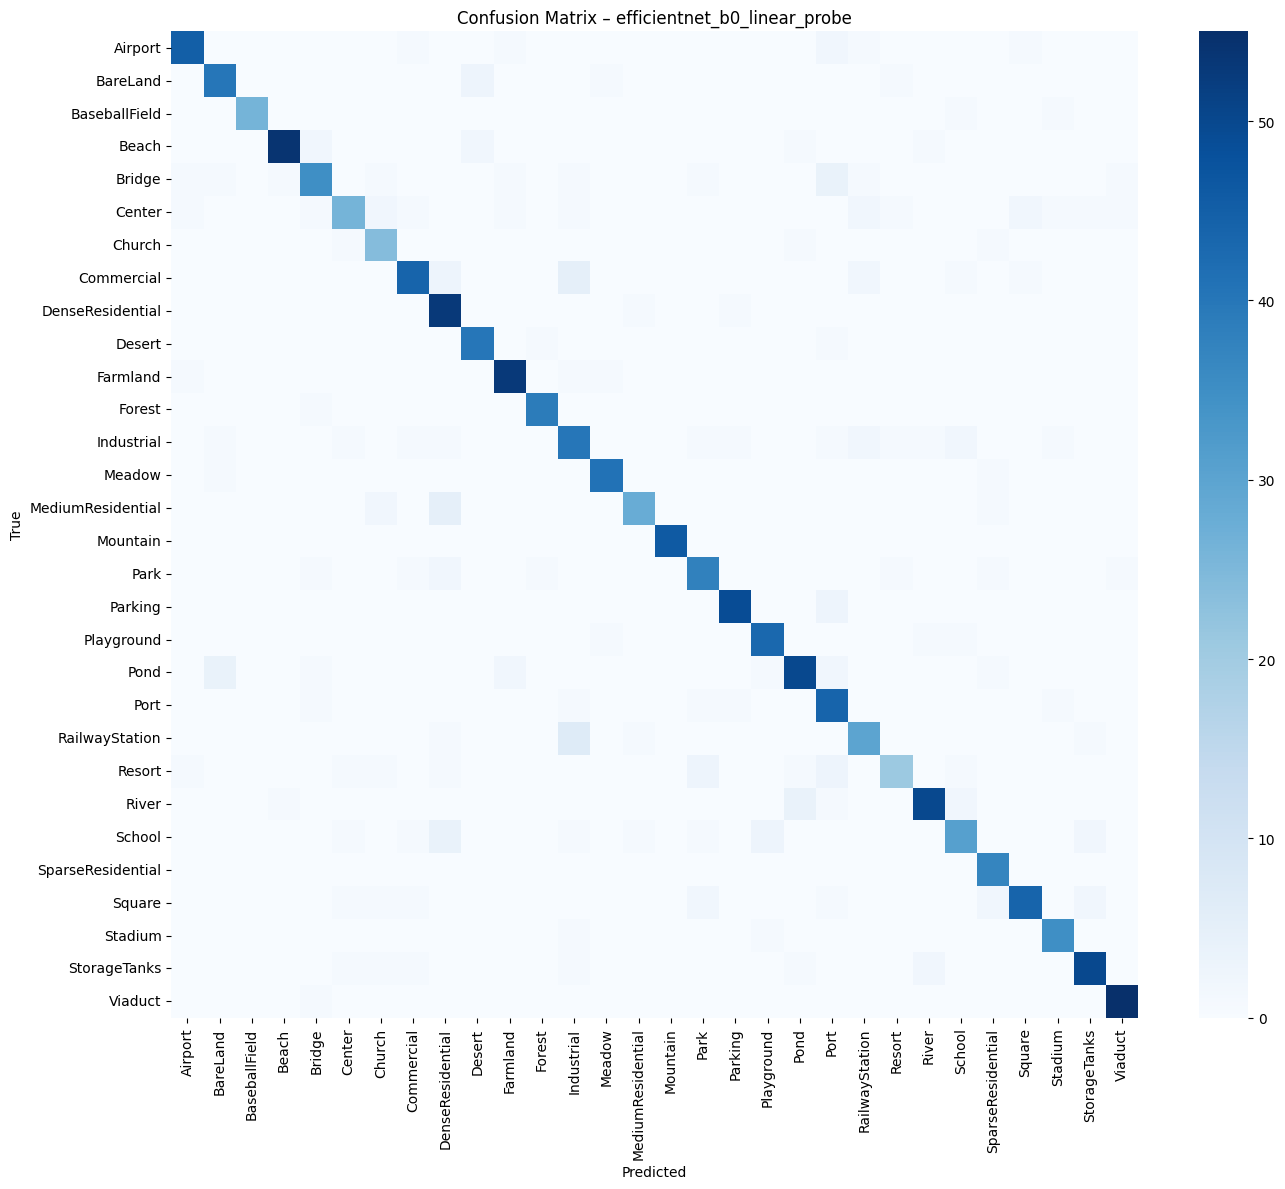

[Plot] Saved → ./output/efficientnet_b0_linear_probe_confusion.png


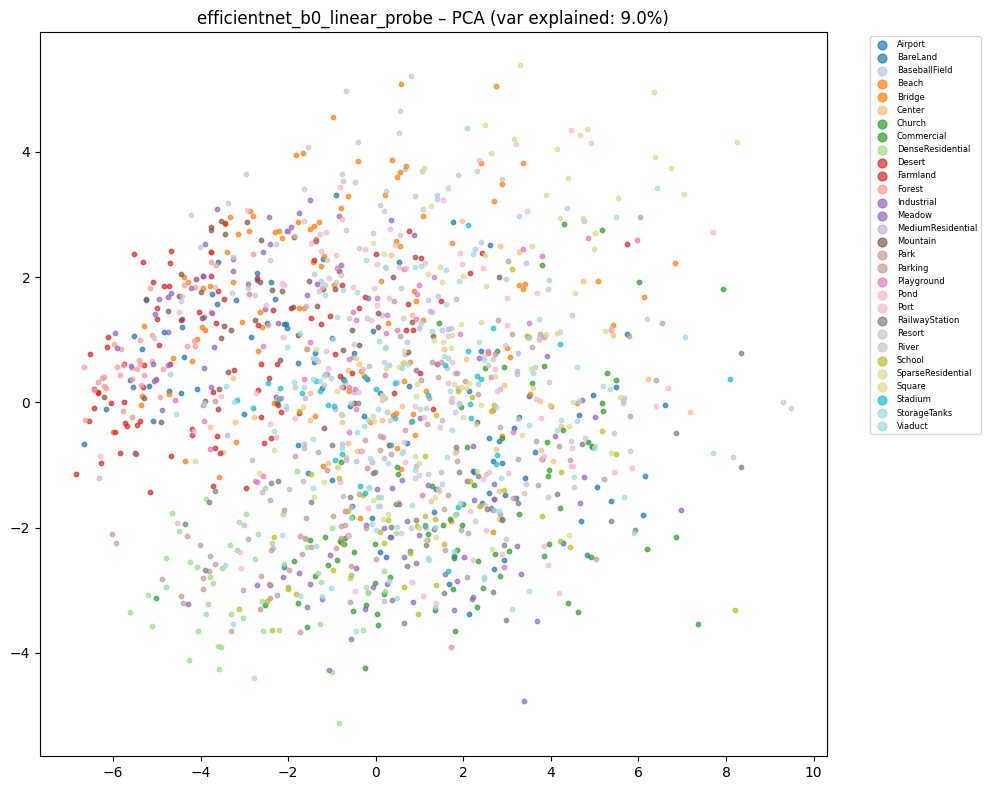

[Plot] Saved → ./output/efficientnet_b0_linear_probe_pca.png

  SCENARIO 4.2 – Full Fine-Tuning: efficientnet_b0
[Model] efficientnet_b0      | total params: 4,045,978 | trainable: 4,045,978 | frozen: False

  Efficiency Metrics: efficientnet_b0_full_ft
  Total parameters     :       4,045,978
  Trainable parameters :       4,045,978
  Frozen parameters    :               0
  MACs                 :     398,111,264  (0.398 G)
  FLOPs (≈2×MACs)      :     796,222,528  (0.796 G)


────────────────────────────────────────────────────────────
  Training: efficientnet_b0_full_ft  |  epochs=30  |  device=cuda
────────────────────────────────────────────────────────────
  Epoch [01/30] | train loss: 1.8960  acc: 59.94% | val loss: 1.1490  acc: 86.28% | 23.0s
  Epoch [02/30] | train loss: 1.0749  acc: 88.38% | val loss: 1.0140  acc: 91.49% | 23.0s
  Epoch [03/30] | train loss: 0.9403  acc: 93.84% | val loss: 0.9594  acc: 92.35% | 23.1s
  Epoch [04/30] | train loss: 0.8738  acc: 95.67% | val los

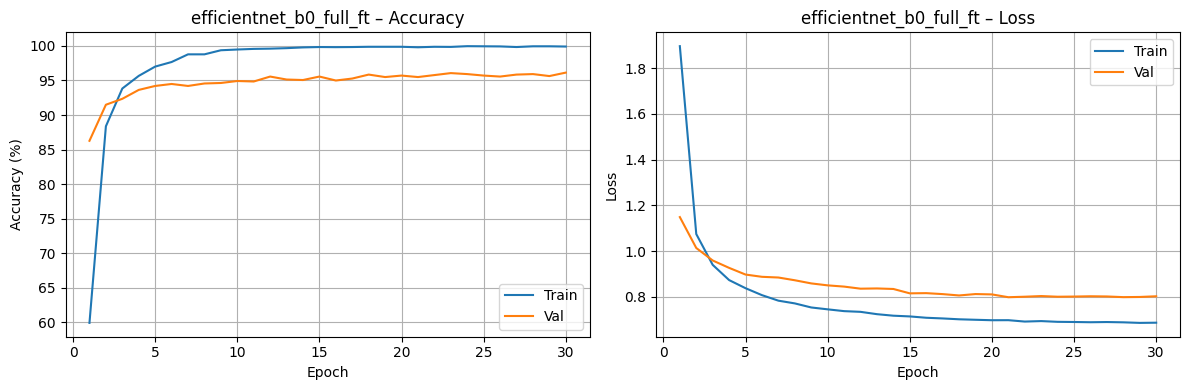

[Plot] Saved → ./output/efficientnet_b0_full_ft_curves.png

  SCENARIO 4.3 – Few-Shot: efficientnet_b0
[Dataset] Classes      : 30
[Dataset] Total images : 6993
[Dataset] Train        : 5594  (fraction=100%)
[Dataset] Val          : 1399
[Model] efficientnet_b0      | total params: 4,045,978 | trainable: 4,045,978 | frozen: False

────────────────────────────────────────────────────────────
  Training: efficientnet_b0_fewshot_100pct  |  epochs=30  |  device=cuda
────────────────────────────────────────────────────────────
  Epoch [01/30] | train loss: 1.4493  acc: 75.54% | val loss: 1.0049  acc: 90.35% | 23.5s
  Epoch [02/30] | train loss: 0.9950  acc: 90.40% | val loss: 0.9556  acc: 91.49% | 23.5s
  Epoch [03/30] | train loss: 0.9056  acc: 93.30% | val loss: 0.9092  acc: 92.42% | 23.5s
  Epoch [04/30] | train loss: 0.8656  acc: 94.84% | val loss: 0.8721  acc: 94.50% | 23.8s
  Epoch [05/30] | train loss: 0.8200  acc: 96.10% | val loss: 0.8947  acc: 93.07% | 23.7s
  Epoch [06/30] | trai

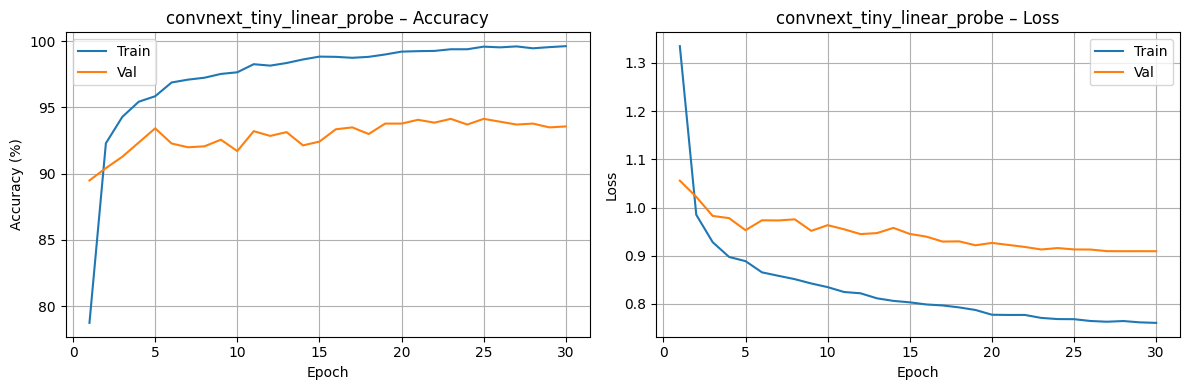

[Plot] Saved → ./output/convnext_tiny_linear_probe_curves.png


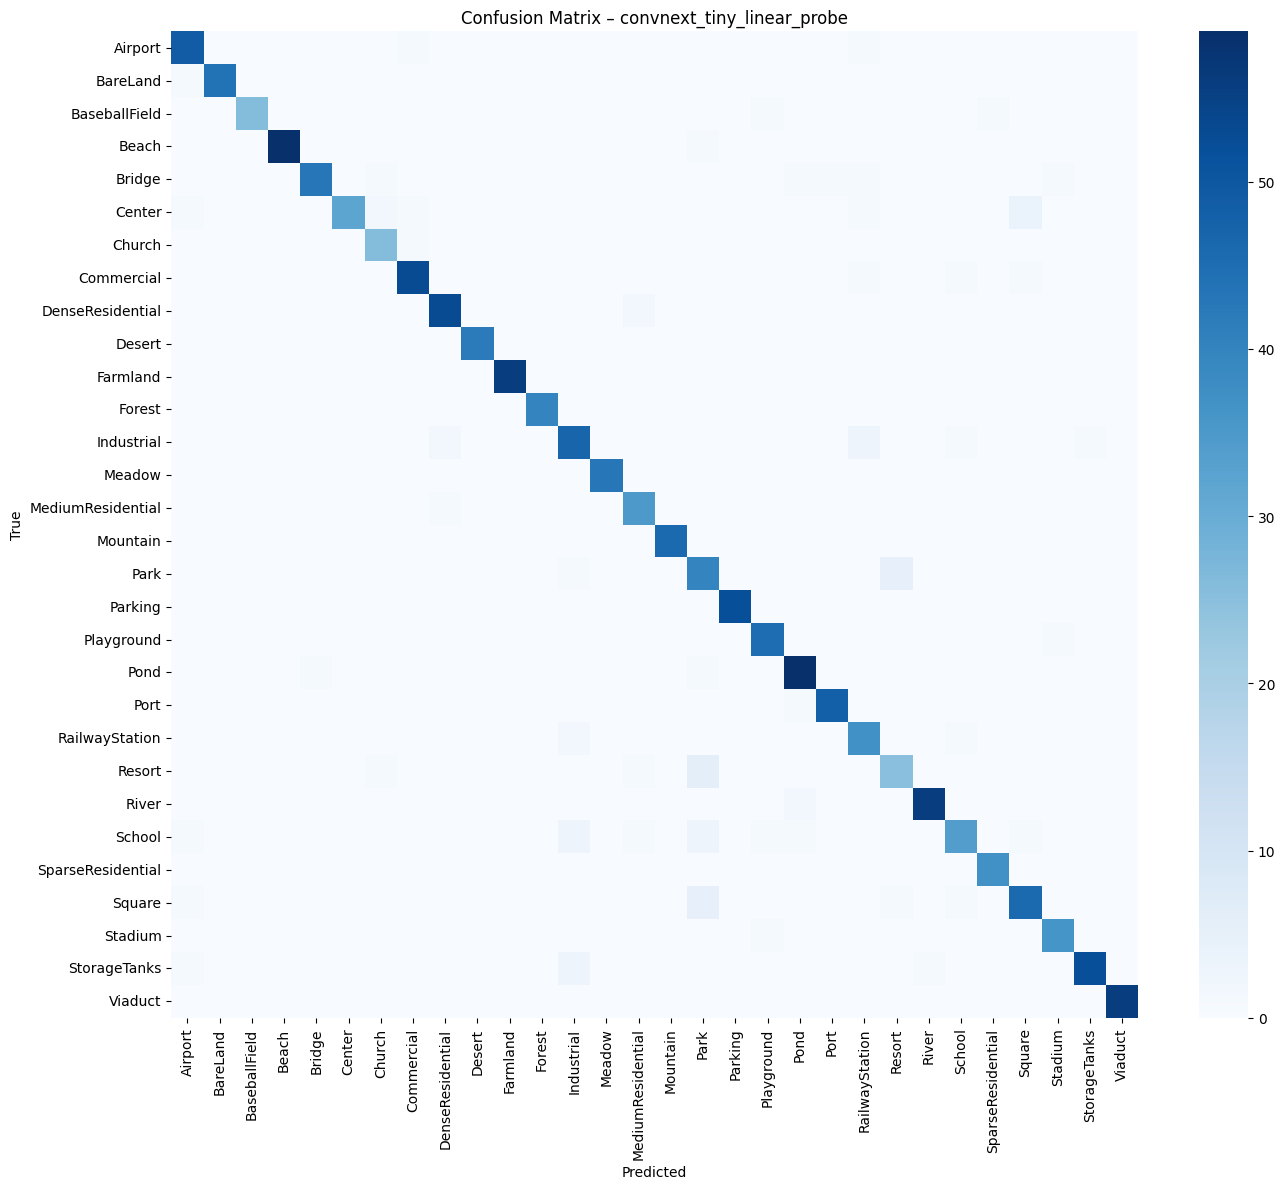

[Plot] Saved → ./output/convnext_tiny_linear_probe_confusion.png


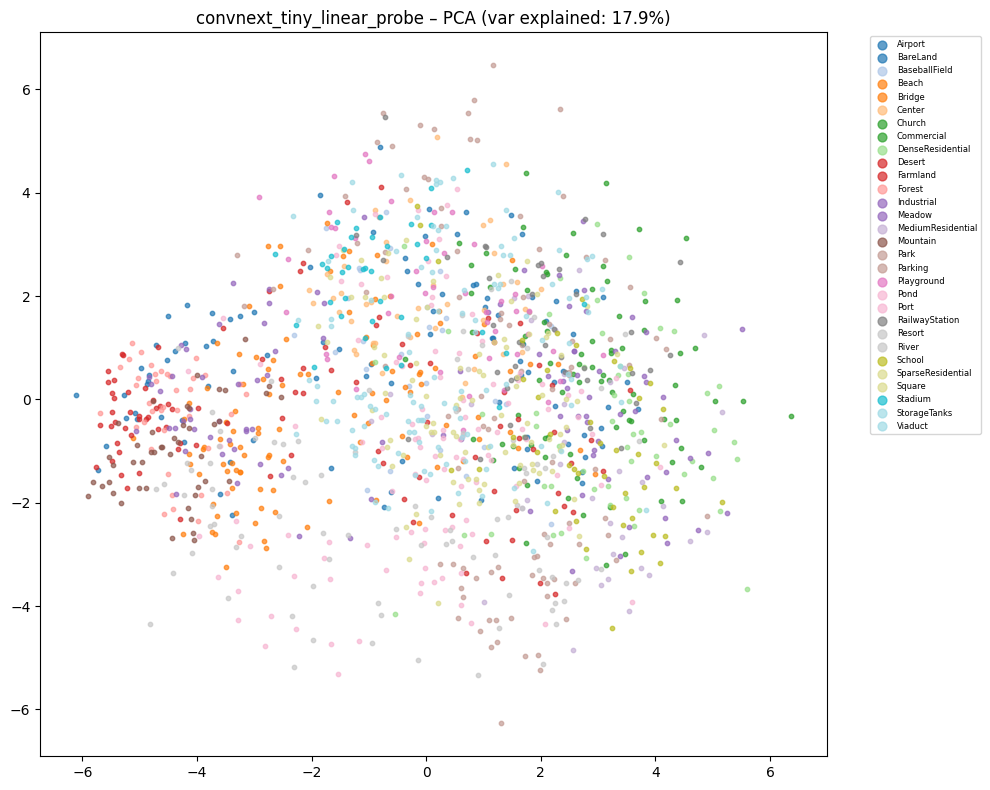

[Plot] Saved → ./output/convnext_tiny_linear_probe_pca.png

  SCENARIO 4.2 – Full Fine-Tuning: convnext_tiny
[Model] convnext_tiny        | total params: 27,843,198 | trainable: 27,843,198 | frozen: False

  Efficiency Metrics: convnext_tiny_full_ft
  Total parameters     :      27,843,198
  Trainable parameters :      27,843,198
  Frozen parameters    :               0
  MACs                 :   4,469,692,416  (4.470 G)
  FLOPs (≈2×MACs)      :   8,939,384,832  (8.939 G)


────────────────────────────────────────────────────────────
  Training: convnext_tiny_full_ft  |  epochs=30  |  device=cuda
────────────────────────────────────────────────────────────
  Epoch [01/30] | train loss: 1.2035  acc: 81.32% | val loss: 0.9022  acc: 91.21% | 78.8s
  Epoch [02/30] | train loss: 0.8064  acc: 94.95% | val loss: 0.8646  acc: 91.71% | 79.1s
  Epoch [03/30] | train loss: 0.7452  acc: 96.97% | val loss: 0.8506  acc: 92.71% | 79.0s
  Epoch [04/30] | train loss: 0.7580  acc: 96.19% | val loss: 0.8

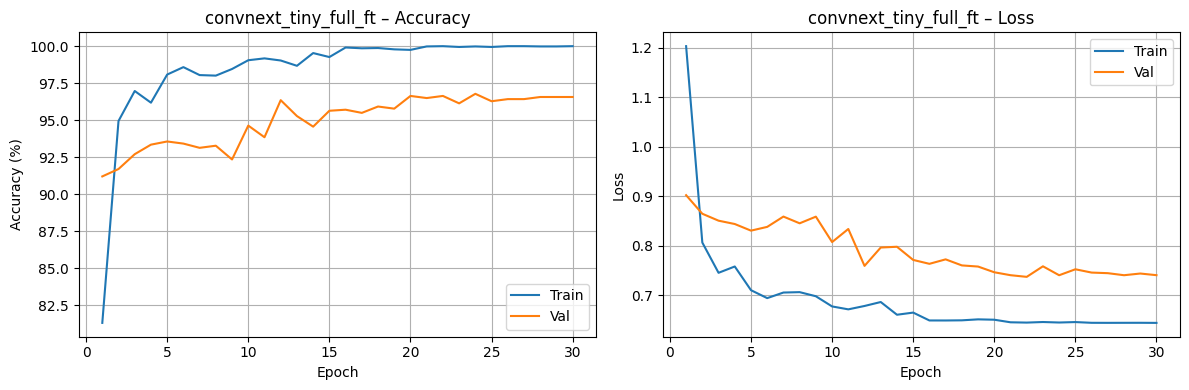

[Plot] Saved → ./output/convnext_tiny_full_ft_curves.png

  SCENARIO 4.3 – Few-Shot: convnext_tiny
[Dataset] Classes      : 30
[Dataset] Total images : 6993
[Dataset] Train        : 5594  (fraction=100%)
[Dataset] Val          : 1399
[Model] convnext_tiny        | total params: 27,843,198 | trainable: 27,843,198 | frozen: False

────────────────────────────────────────────────────────────
  Training: convnext_tiny_fewshot_100pct  |  epochs=30  |  device=cuda
────────────────────────────────────────────────────────────
  Epoch [01/30] | train loss: 3.4516  acc: 4.71% | val loss: 3.2481  acc: 7.93% | 78.9s
  Epoch [02/30] | train loss: 2.9831  acc: 13.90% | val loss: 2.8037  acc: 20.66% | 79.2s
  Epoch [03/30] | train loss: 2.6335  acc: 25.30% | val loss: 2.5395  acc: 25.16% | 79.3s
  Epoch [04/30] | train loss: 2.4602  acc: 31.81% | val loss: 2.2917  acc: 36.24% | 79.1s
  Epoch [05/30] | train loss: 2.3206  acc: 37.21% | val loss: 2.2422  acc: 37.74% | 78.9s
  Epoch [06/30] | train loss

In [ ]:

# SECTION 12: Orchestration – Run All Experiments


def main():
    set_seed(SEED)
    cfg = CONFIG
    device = cfg["device"]

    print(f"\n{'#'*60}")
    print("  GNR638 Assignment-2 | Starting experiments")
    print(f"  Device: {device}")
    print(f"{'#'*60}\n")

    train_loader, val_loader, class_names = build_dataloaders(
        data_root=cfg["data_root"],
        image_size=cfg["image_size"],
        batch_size=cfg["batch_size"],
        train_split=cfg["train_split"],
        num_workers=cfg["num_workers"],
        fraction=1.0,
        seed=cfg["seed"],
    )

    all_results = {}

    for model_key in MODEL_NAMES.keys():
        print(f"\n{'#'*60}")
        print(f"  Model: {model_key.upper()}")
        print(f"{'#'*60}")

        # 4.1  Linear Probe 
        lp_history, lp_acc, lp_metrics = run_linear_probe(
            model_key, train_loader, val_loader, class_names, cfg)

        #4.2  Full Fine-Tuning (for convergence / gradient analysis) 
        print(f"\n  SCENARIO 4.2 – Full Fine-Tuning: {model_key}")
        ft_model  = load_model(model_key, num_classes=cfg["num_classes"],
                               pretrained=True, freeze_backbone=False)
        print_efficiency_metrics(ft_model, f"{model_key}_full_ft",
                                 cfg["image_size"], device)
        ft_history, ft_acc = train_model(
            ft_model, train_loader, val_loader,
            num_epochs=cfg["max_epochs"],
            lr=cfg["learning_rate"] * 0.1, 
            weight_decay=cfg["weight_decay"],
            device=device,
            model_name=f"{model_key}_full_ft",
            save_best=True,
            output_dir=cfg["output_dir"],
        )
        plot_training_curves(ft_history, f"{model_key}_full_ft", cfg["output_dir"])

        fs_results = run_few_shot(model_key, val_loader, class_names, cfg)
        # ── 4.4  Corruption Robustness 
        corruption_rows = run_corruption_eval(
            ft_model, model_key, ft_acc, cfg)

        # ── Store results
        all_results[model_key] = {
            "linear_probe": {"history": lp_history, "best_acc": lp_acc,
                             "metrics": lp_metrics},
            "full_finetune": {"history": ft_history, "best_acc": ft_acc},
            "few_shot":      fs_results,
            "corruption":    corruption_rows,
        }

    print("\n\n" + "=" * 70)
    print("  SUMMARY: Best Validation Accuracy")
    print("=" * 70)
    print(f"  {'Model':<20} {'LinearProbe':>12}  {'FullFineTune':>14}")
    print("  " + "-" * 50)
    for k, v in all_results.items():
        lp = v["linear_probe"]["best_acc"]
        ft = v["full_finetune"]["best_acc"]
        print(f"  {k:<20} {lp:>11.2f}%  {ft:>13.2f}%")
    print("=" * 70 + "\n")

    return all_results



# SECTION 13: Entry Point


if __name__ == "__main__":
    results = main()

In [ ]:
import os
import math
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# HELPER: parameter bookkeeping
def _count(model: nn.Module, only_trainable: bool = False) -> int:
    """Return total (or trainable-only) parameter count."""
    return sum(
        p.numel() for p in model.parameters()
        if (p.requires_grad if only_trainable else True)
    )


def _freeze_all(model: nn.Module):
    """Freeze every parameter in the model."""
    for p in model.parameters():
        p.requires_grad = False


def _unfreeze_module(module: nn.Module):
    """Unfreeze every parameter inside a given sub-module."""
    for p in module.parameters():
        p.requires_grad = True


def param_summary(model: nn.Module, label: str) -> dict:
    """Print and return a dict with total / trainable / frozen / pct stats."""
    total     = _count(model, only_trainable=False)
    trainable = _count(model, only_trainable=True)
    frozen    = total - trainable
    pct       = 100.0 * trainable / total if total else 0.0
    print(f"  [{label}]  total={total:,}  trainable={trainable:,}  "
          f"frozen={frozen:,}  unfrozen={pct:.2f}%")
    return dict(total=total, trainable=trainable,
                frozen=frozen, pct_unfrozen=pct)


# STRATEGY A Linear Probe  (head only)

def apply_linear_probe(model: nn.Module) -> nn.Module:
    _freeze_all(model)
    _unfreeze_module(model.get_classifier())
    return model


# STRATEGY B  Last-Block Fine-Tuning

def unfreeze_last_block(model: nn.Module, model_key: str) -> nn.Module:

    _freeze_all(model)
    _unfreeze_module(model.get_classifier())

    if model_key == "resnet50":
        _unfreeze_module(model.layer4)

    elif model_key == "efficientnet_b0":
        # timm EfficientNet: model.blocks is an nn.Sequential of MBConv groups
        _unfreeze_module(model.blocks[-1])
        if hasattr(model, "conv_head"):
            _unfreeze_module(model.conv_head)
        if hasattr(model, "bn2"):
            _unfreeze_module(model.bn2)

    elif model_key == "convnext_tiny":
        # timm ConvNeXt: model.stages is an nn.Sequential of 4 ConvNeXt stages
        _unfreeze_module(model.stages[-1])
        for attr in ("norm_pre", "head_norm"):
            if hasattr(model, attr):
                _unfreeze_module(getattr(model, attr))

    else:
        raise ValueError(f"unfreeze_last_block: unsupported model_key '{model_key}'")

    return model


# STRATEGY C  Selective 20% Unfreezing

def unfreeze_20_percent(model: nn.Module) -> nn.Module:
    _freeze_all(model)

    total_params = _count(model, only_trainable=False)
    budget       = math.floor(0.20 * total_params)
    remaining    = budget

    # Collect (name, module) in forward-pass order, then reverse
    all_modules  = list(model.named_modules())  
    # Filter to leaf modules (actual parameter holders) to avoid double counting
    leaf_modules = [
        (name, mod) for name, mod in all_modules
        if len(list(mod.children())) == 0 and len(list(mod.parameters())) > 0
    ]
    leaf_modules_reversed = list(reversed(leaf_modules))

    unfrozen_count = 0
    for name, mod in leaf_modules_reversed:
        if remaining <= 0:
            break

        mod_params     = list(mod.parameters())
        mod_param_count = sum(p.numel() for p in mod_params)

        if mod_param_count <= remaining:
            # Whole module fits inside budget → unfreeze entirely
            _unfreeze_module(mod)
            remaining      -= mod_param_count
            unfrozen_count += mod_param_count
        else:
            # Partial: unfreeze individual parameters until budget runs out
            for p in mod_params:
                if p.numel() <= remaining:
                    p.requires_grad = True
                    remaining      -= p.numel()
                    unfrozen_count += p.numel()
                if remaining <= 0:
                    break

    actual_pct = 100.0 * unfrozen_count / total_params
    print(f"  [unfreeze_20%]  budget={budget:,}  "
          f"actually_unfrozen={unfrozen_count:,}  ({actual_pct:.2f}%)")
    return model

# STRATEGY D  ──  Full Fine-Tuning

def apply_full_finetune(model: nn.Module) -> nn.Module:
    """Unfreeze every parameter (standard full fine-tuning)."""
    for p in model.parameters():
        p.requires_grad = True
    return model

# GRADIENT NORM TRACKING

def compute_layerwise_grad_norms(model: nn.Module) -> dict[str, float]:
    norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms[name] = param.grad.detach().norm(2).item()
    return norms


def _train_one_epoch_with_grad_norms(model, loader, criterion,
                                     optimizer, device):
    model.train()
    total_loss = correct = seen = 0

    # Accumulate norms across batches then average
    norm_accumulator: dict[str, list] = {}

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Collect norms BEFORE the optimiser step (so grads are intact)
        batch_norms = compute_layerwise_grad_norms(model)
        for k, v in batch_norms.items():
            norm_accumulator.setdefault(k, []).append(v)

        optimizer.step()

        preds    = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total_loss += loss.item() * images.size(0)
        seen    += images.size(0)

    avg_loss  = total_loss / seen
    accuracy  = 100.0 * correct / seen
    avg_norms = {k: float(np.mean(v)) for k, v in norm_accumulator.items()}
    return avg_loss, accuracy, avg_norms


# TRAINING WRAPPER WITH GRADIENT NORM COLLECTION

def train_with_grad_tracking(
    model:       nn.Module,
    train_loader,
    val_loader,
    num_epochs:  int   = 30,
    lr:          float = 1e-3,
    weight_decay: float = 1e-4,
    device:      str   = "cpu",
    model_name:  str   = "model",
    save_best:   bool  = True,
    output_dir:  str   = ".",
):
    
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    history = dict(train_loss=[], train_acc=[], val_loss=[], val_acc=[])
    grad_history: dict[str, list] = {}
    best_val_acc = 0.0
    best_state   = None

    print(f"\n  ── Training: {model_name} ({num_epochs} epochs) ──")

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, grad_norms = _train_one_epoch_with_grad_norms(
            model, train_loader, criterion, optimizer, device)

        # Validation 
        model.eval()
        va_loss = va_correct = va_seen = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out     = model(imgs)
                va_loss += criterion(out, lbls).item() * imgs.size(0)
                va_correct += (out.argmax(1) == lbls).sum().item()
                va_seen    += imgs.size(0)
        va_loss /= va_seen
        va_acc   = 100.0 * va_correct / va_seen

        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        for param_name, norm_val in grad_norms.items():
            grad_history.setdefault(param_name, []).append(norm_val)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = copy.deepcopy(model.state_dict())
            if save_best:
                path = os.path.join(output_dir, f"{model_name}_best.pth")
                torch.save(best_state, path)

        print(f"    Epoch [{epoch:02d}/{num_epochs}] "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.2f}%  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.2f}%")

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"  ✓ Best val acc ({model_name}): {best_val_acc:.2f}%")
    return history, best_val_acc, grad_history


# VISUALISATION  ──  Scenario 4.2-specific plots

STRATEGY_COLORS = {
    "linear_probe": "#4C72B0",
    "last_block":   "#DD8452",
    "selective_20": "#55A868",
    "full_ft":      "#C44E52",
}

STRATEGY_LABELS = {
    "linear_probe": "Linear Probe",
    "last_block":   "Last Block",
    "selective_20": "Selective 20%",
    "full_ft":      "Full Fine-Tune",
}


def plot_convergence_comparison(all_histories: dict, model_key: str,
                                save_dir: str = "."):
    fig, ax = plt.subplots(figsize=(9, 5))

    for strategy, history in all_histories.items():
        epochs = range(1, len(history["train_loss"]) + 1)
        ax.plot(epochs, history["train_loss"],
                color=STRATEGY_COLORS[strategy],
                label=STRATEGY_LABELS[strategy],
                linewidth=1.8)

    ax.set_title(f"{model_key.upper()} — Training Loss vs Epoch (Scenario 4.2)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    path = os.path.join(save_dir, f"{model_key}_4_2_convergence.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] {path}")


def plot_accuracy_vs_unfrozen(summary_rows: list, save_dir: str = "."):
    from itertools import groupby

    fig, ax = plt.subplots(figsize=(9, 5))
    markers = {"resnet50": "o", "efficientnet_b0": "s", "convnext_tiny": "^"}
    model_colors = {"resnet50": "#4C72B0",
                    "efficientnet_b0": "#DD8452",
                    "convnext_tiny": "#55A868"}

    # Group by model
    rows_by_model: dict[str, list] = {}
    for row in summary_rows:
        rows_by_model.setdefault(row["model_key"], []).append(row)

    for mk, rows in rows_by_model.items():
        rows_sorted = sorted(rows, key=lambda r: r["pct_unfrozen"])
        xs = [r["pct_unfrozen"] for r in rows_sorted]
        ys = [r["best_val_acc"] for r in rows_sorted]
        ax.plot(xs, ys, marker=markers[mk], color=model_colors[mk],
                linewidth=1.8, markersize=8, label=mk)

        # Annotate each point with strategy name
        for r in rows_sorted:
            ax.annotate(STRATEGY_LABELS[r["strategy"]],
                        (r["pct_unfrozen"], r["best_val_acc"]),
                        textcoords="offset points", xytext=(5, 4),
                        fontsize=7, color=model_colors[mk])

    ax.set_title("Val Accuracy vs % Unfrozen Parameters (Scenario 4.2)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("% Unfrozen Parameters")
    ax.set_ylabel("Best Validation Accuracy (%)")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    path = os.path.join(save_dir, "4_2_accuracy_vs_unfrozen.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Plot] {path}")


def plot_gradient_norm_heatmap(grad_history: dict, model_name: str,
                               top_n: int = 20, save_dir: str = "."):
    """
    Heatmap of gradient norms over epochs for the top-N most active layers.
    """
    if not grad_history:
        print(f"[GradNorm] No gradient data for {model_name}; skipping.")
        return

    # Sort parameters by descending mean gradient norm
    sorted_params = sorted(
        grad_history.items(),
        key=lambda kv: np.mean(kv[1]),
        reverse=True,
    )[:top_n]

    param_names = [k.replace(".", "\n") for k, _ in sorted_params]
    matrix      = np.array([v for _, v in sorted_params])   # (actual_n, epochs)
    actual_n    = len(param_names) 

    fig, ax = plt.subplots(figsize=(max(10, matrix.shape[1] * 0.4),
                                    max(2, actual_n * 0.4)))
    import matplotlib.colors as mcolors
    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd",
                   norm=mcolors.LogNorm(
                       vmin=max(matrix.min(), 1e-10),
                       vmax=matrix.max() + 1e-10))
    plt.colorbar(im, ax=ax, label="Gradient L2 norm (log scale)")

    ax.set_yticks(range(actual_n))
    ax.set_yticklabels(param_names, fontsize=6)
    ax.set_xlabel("Epoch")
    ax.set_title(f"{model_name} — Layer-Wise Gradient Norms (top {actual_n})",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(save_dir, f"{model_name}_grad_norm_heatmap.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig) 
    print(f"[Plot] {path}")


def plot_grad_norm_over_epochs(grad_history: dict, model_name: str,
                               top_n: int = 8, save_dir: str = "."):
    """
    Line plot of gradient norms over epochs for the top-N active layers.
    """
    if not grad_history:
        return

    sorted_params = sorted(
        grad_history.items(),
        key=lambda kv: np.mean(kv[1]),
        reverse=True,
    )[:top_n]
    
    actual_n = len(sorted_params) 

    fig, ax = plt.subplots(figsize=(10, 5))
    cmap    = plt.cm.tab10
    for i, (pname, norms) in enumerate(sorted_params):
        epochs = range(1, len(norms) + 1)
        short  = ".".join(pname.split(".")[-3:])
        ax.plot(epochs, norms, color=cmap(i % 10), label=short, linewidth=1.5)

    ax.set_title(f"{model_name} — Gradient Norm Dynamics (top {actual_n} layers)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Gradient L2 Norm")
    ax.set_yscale("log")
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    path = os.path.join(save_dir, f"{model_name}_grad_norm_lines.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig) # Close the figure to free memory
    print(f"[Plot] {path}")

# MAIN ORCHESTRATOR  ──  run_scenario_4_2()
def run_scenario_4_2(
    train_loader,
    val_loader,
    cfg:       dict = None,
    model_keys: list = None,
):
   
    if cfg is None:
        cfg = CONFIG  

    if model_keys is None:
        model_keys = list(MODEL_NAMES.keys())  

    device     = cfg["device"]
    output_dir = cfg["output_dir"]
    num_classes = cfg["num_classes"]
    num_epochs  = cfg["max_epochs"]
    lr          = cfg["learning_rate"]
    wd          = cfg["weight_decay"]

    LR_OVERRIDES = {
        "linear_probe": lr,
        "last_block":   lr,
        "selective_20": lr,
        "full_ft":      lr * 0.1,
    }

    #Strategy definitions  (apply_fn receives (model, model_key)) 
    STRATEGIES = {
        "linear_probe": lambda m, mk: apply_linear_probe(m),
        "last_block":   lambda m, mk: unfreeze_last_block(m, mk),
        "selective_20": lambda m, mk: unfreeze_20_percent(m),
        "full_ft":      lambda m, mk: apply_full_finetune(m),
    }

    results      = {}
    summary_rows = []   # for the accuracy-vs-unfrozen plot

    for model_key in model_keys:
        print(f"\n{'═'*65}")
        print(f"  MODEL: {model_key.upper()}")
        print(f"{'═'*65}")

        model_results    = {}
        all_histories    = {}   # strategy → history  (for convergence plot)

        for strategy_key, apply_fn in STRATEGIES.items():
            print(f"\n  ── Strategy: {STRATEGY_LABELS[strategy_key]} ──")

            # Fresh copy of pretrained weights for every strategy
            model = load_model( 
                model_key,
                num_classes=num_classes,
                pretrained=True,
            )

            # Apply the freezing / unfreezing strategy
            model = apply_fn(model, model_key)
            # Log parameter breakdown
            stats = param_summary(model, STRATEGY_LABELS[strategy_key])

            # Train with gradient norm tracking
            run_name = f"{model_key}_{strategy_key}"
            history, best_acc, grad_history = train_with_grad_tracking(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                num_epochs=num_epochs,
                lr=LR_OVERRIDES[strategy_key],
                weight_decay=wd,
                device=device,
                model_name=run_name,
                save_best=True,
                output_dir=output_dir,
            )

            # ── Standard training curves (uses existing utility)
            plot_training_curves( 
                history, run_name, output_dir)

            # ── Gradient norm visualisations 
            plot_gradient_norm_heatmap(
                grad_history, run_name, top_n=20, save_dir=output_dir)
            plot_grad_norm_over_epochs(
                grad_history, run_name, top_n=8,  save_dir=output_dir)

            # Accumulate
            model_results[strategy_key] = dict(
                history=history,
                best_acc=best_acc,
                grad_history=grad_history,
                pct_unfrozen=stats["pct_unfrozen"],
                stats=stats,
            )
            all_histories[strategy_key] = history

            summary_rows.append(dict(
                model_key=model_key,
                strategy=strategy_key,
                pct_unfrozen=stats["pct_unfrozen"],
                best_val_acc=best_acc,
            ))

            del model                  # 1. Delete the heavy model variable
            gc.collect()               # 2. Force Python to clean up the trash
            torch.cuda.empty_cache()   # 3. Force the GPU to empty its VRAM

        # Per-model convergence overlay 
        plot_convergence_comparison(all_histories, model_key, output_dir)

        results[model_key] = model_results

    # Cross-model accuracy vs. % unfrozen scatter
    plot_accuracy_vs_unfrozen(summary_rows, output_dir)

    # Summary table 
    print("\n\n" + "═" * 75)
    print("  SCENARIO 4.2 SUMMARY")
    print("═" * 75)
    header = f"  {'Model':<20} {'Strategy':<20} {'%Unfrozen':>10}  {'BestValAcc':>12}"
    print(header)
    print("  " + "─" * 66)
    for row in summary_rows:
        print(f"  {row['model_key']:<20} "
              f"{STRATEGY_LABELS[row['strategy']]:<20} "
              f"{row['pct_unfrozen']:>9.2f}%  "
              f"{row['best_val_acc']:>11.2f}%")
    print("═" * 75 + "\n")

    return results


[Dataset] Classes      : 30
[Dataset] Total images : 6993
[Dataset] Train        : 5594  (fraction=100%)
[Dataset] Val          : 1399
Starting Scenario 4.2...

═════════════════════════════════════════════════════════════════
  MODEL: RESNET50
═════════════════════════════════════════════════════════════════

  ── Strategy: Linear Probe ──
[Model] resnet50             | total params: 23,569,502 | trainable: 23,569,502 | frozen: False
  [Linear Probe]  total=23,569,502  trainable=61,470  frozen=23,508,032  unfrozen=0.26%

  ── Training: resnet50_linear_probe (30 epochs) ──
    Epoch [01/30] train_loss=2.5446  train_acc=49.43%  val_loss=2.0414  val_acc=71.77%
    Epoch [02/30] train_loss=1.7998  train_acc=71.58%  val_loss=1.6365  val_acc=78.06%
    Epoch [03/30] train_loss=1.5565  train_acc=76.43%  val_loss=1.4878  val_acc=79.63%
    Epoch [04/30] train_loss=1.4447  train_acc=78.53%  val_loss=1.4168  val_acc=79.27%
    Epoch [05/30] train_loss=1.3794  train_acc=80.14%  val_loss=1.3340  

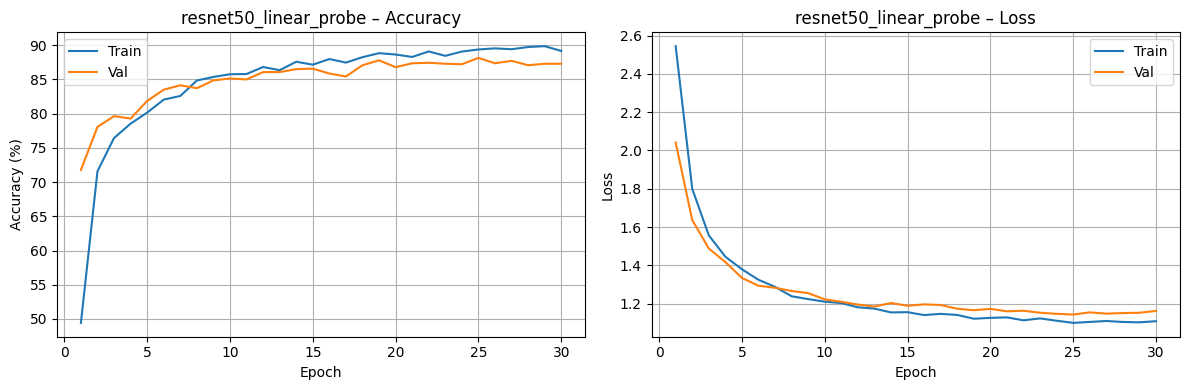

[Plot] Saved → ./output/resnet50_linear_probe_curves.png
[Plot] ./output/resnet50_linear_probe_grad_norm_heatmap.png
[Plot] ./output/resnet50_linear_probe_grad_norm_lines.png

  ── Strategy: Last Block ──
[Model] resnet50             | total params: 23,569,502 | trainable: 23,569,502 | frozen: False
  [Last Block]  total=23,569,502  trainable=15,026,206  frozen=8,543,296  unfrozen=63.75%

  ── Training: resnet50_last_block (30 epochs) ──
    Epoch [01/30] train_loss=1.6328  train_acc=67.78%  val_loss=1.0191  val_acc=89.56%
    Epoch [02/30] train_loss=1.0106  train_acc=88.95%  val_loss=0.9296  val_acc=92.14%
    Epoch [03/30] train_loss=0.9382  train_acc=91.91%  val_loss=0.9206  val_acc=93.07%
    Epoch [04/30] train_loss=0.8896  train_acc=93.14%  val_loss=0.9200  val_acc=93.35%
    Epoch [05/30] train_loss=0.8524  train_acc=94.70%  val_loss=0.9091  val_acc=93.92%
    Epoch [06/30] train_loss=0.8435  train_acc=95.36%  val_loss=0.8861  val_acc=93.78%
    Epoch [07/30] train_loss=0.8208 

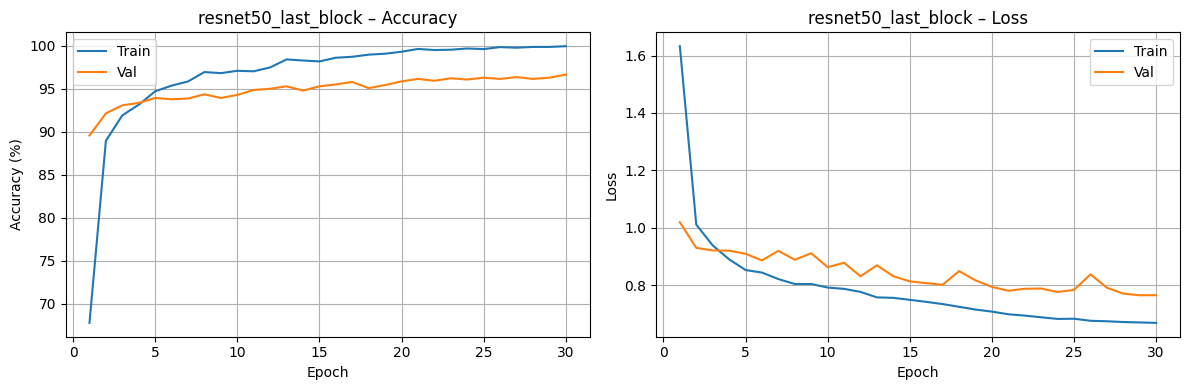

[Plot] Saved → ./output/resnet50_last_block_curves.png
[Plot] ./output/resnet50_last_block_grad_norm_heatmap.png
[Plot] ./output/resnet50_last_block_grad_norm_lines.png

  ── Strategy: Selective 20% ──
[Model] resnet50             | total params: 23,569,502 | trainable: 23,569,502 | frozen: False
  [unfreeze_20%]  budget=4,713,900  actually_unfrozen=4,706,206  (19.97%)
  [Selective 20%]  total=23,569,502  trainable=4,706,206  frozen=18,863,296  unfrozen=19.97%

  ── Training: resnet50_selective_20 (30 epochs) ──
    Epoch [01/30] train_loss=1.8072  train_acc=61.89%  val_loss=1.1328  val_acc=86.70%
    Epoch [02/30] train_loss=1.0904  train_acc=86.62%  val_loss=0.9876  val_acc=91.28%
    Epoch [03/30] train_loss=0.9889  train_acc=90.69%  val_loss=0.9705  val_acc=91.35%
    Epoch [04/30] train_loss=0.9452  train_acc=91.89%  val_loss=0.9339  val_acc=93.07%
    Epoch [05/30] train_loss=0.8852  train_acc=94.61%  val_loss=0.9432  val_acc=93.35%
    Epoch [06/30] train_loss=0.8647  train_acc=

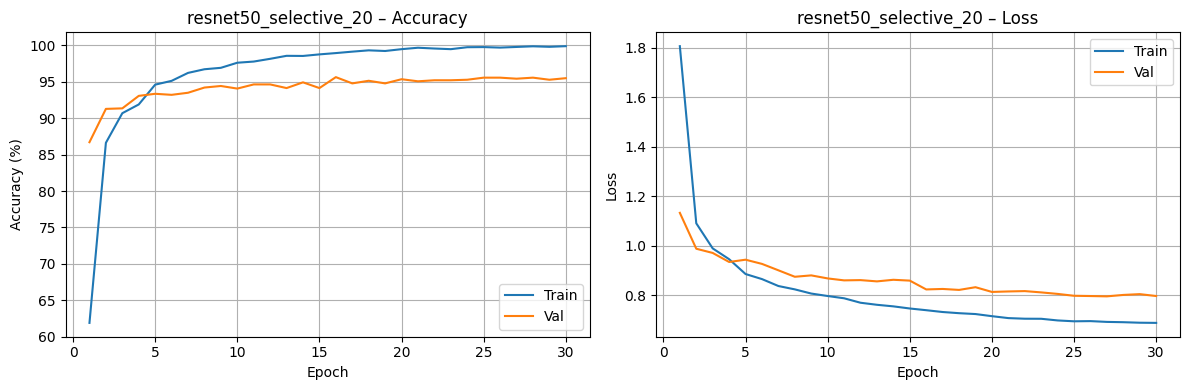

[Plot] Saved → ./output/resnet50_selective_20_curves.png
[Plot] ./output/resnet50_selective_20_grad_norm_heatmap.png
[Plot] ./output/resnet50_selective_20_grad_norm_lines.png

  ── Strategy: Full Fine-Tune ──
[Model] resnet50             | total params: 23,569,502 | trainable: 23,569,502 | frozen: False
  [Full Fine-Tune]  total=23,569,502  trainable=23,569,502  frozen=0  unfrozen=100.00%

  ── Training: resnet50_full_ft (30 epochs) ──
    Epoch [01/30] train_loss=2.9483  train_acc=34.10%  val_loss=1.9862  val_acc=67.26%
    Epoch [02/30] train_loss=1.6147  train_acc=71.92%  val_loss=1.1233  val_acc=87.13%
    Epoch [03/30] train_loss=1.1727  train_acc=83.88%  val_loss=0.9658  val_acc=90.42%
    Epoch [04/30] train_loss=1.0148  train_acc=88.56%  val_loss=0.8964  val_acc=93.07%
    Epoch [05/30] train_loss=0.9383  train_acc=91.12%  val_loss=0.8572  val_acc=93.85%
    Epoch [06/30] train_loss=0.8913  train_acc=92.94%  val_loss=0.8530  val_acc=93.78%
    Epoch [07/30] train_loss=0.8482  t

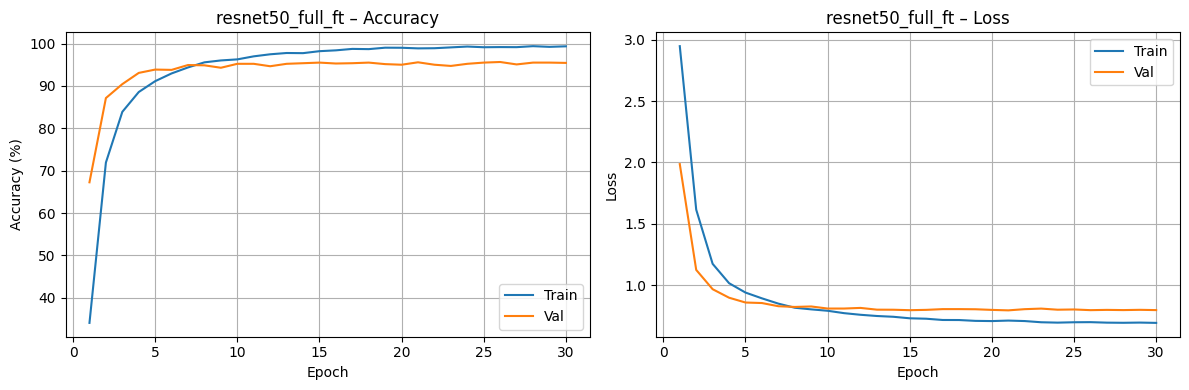

[Plot] Saved → ./output/resnet50_full_ft_curves.png
[Plot] ./output/resnet50_full_ft_grad_norm_heatmap.png
[Plot] ./output/resnet50_full_ft_grad_norm_lines.png


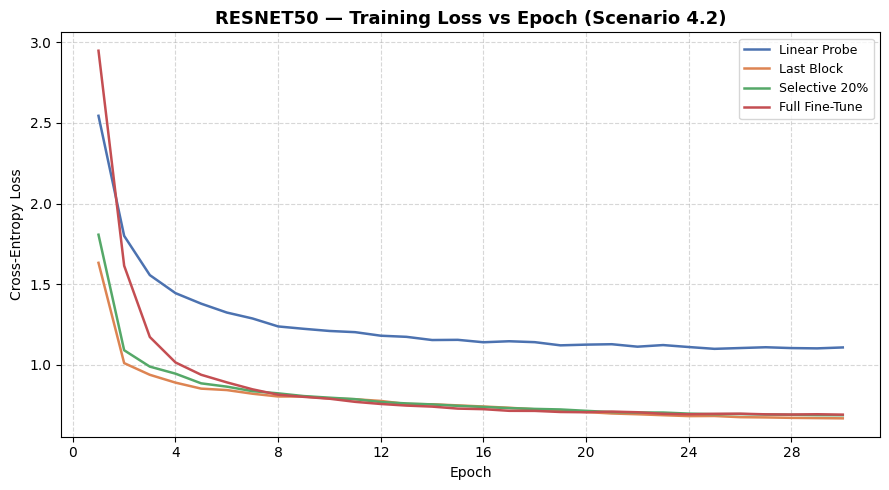

[Plot] ./output/resnet50_4_2_convergence.png

═════════════════════════════════════════════════════════════════
  MODEL: EFFICIENTNET_B0
═════════════════════════════════════════════════════════════════

  ── Strategy: Linear Probe ──
[Model] efficientnet_b0      | total params: 4,045,978 | trainable: 4,045,978 | frozen: False
  [Linear Probe]  total=4,045,978  trainable=38,430  frozen=4,007,548  unfrozen=0.95%

  ── Training: efficientnet_b0_linear_probe (30 epochs) ──
    Epoch [01/30] train_loss=2.3562  train_acc=43.77%  val_loss=1.6299  val_acc=66.55%
    Epoch [02/30] train_loss=1.5728  train_acc=69.29%  val_loss=1.4190  val_acc=75.48%
    Epoch [03/30] train_loss=1.4061  train_acc=75.91%  val_loss=1.3327  val_acc=79.06%
    Epoch [04/30] train_loss=1.3337  train_acc=78.53%  val_loss=1.2926  val_acc=81.13%
    Epoch [05/30] train_loss=1.2716  train_acc=81.02%  val_loss=1.2696  val_acc=81.20%
    Epoch [06/30] train_loss=1.2439  train_acc=82.00%  val_loss=1.2493  val_acc=83.13%
   

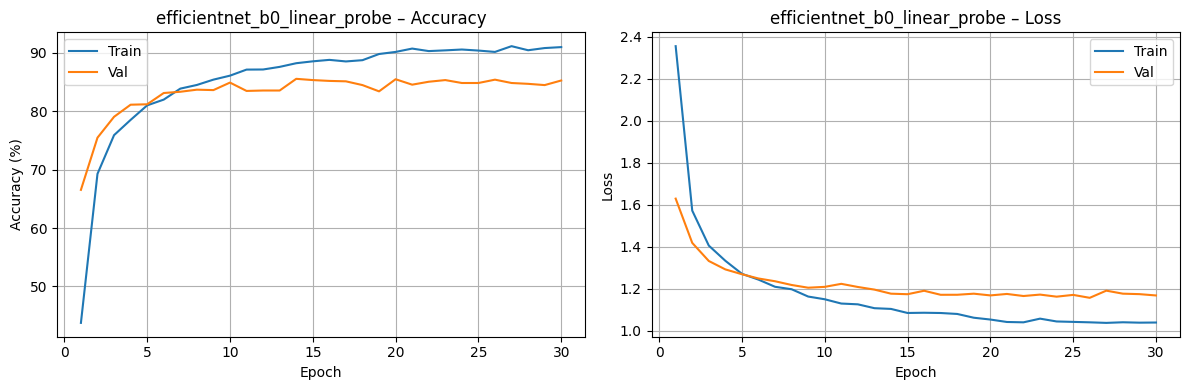

[Plot] Saved → ./output/efficientnet_b0_linear_probe_curves.png
[Plot] ./output/efficientnet_b0_linear_probe_grad_norm_heatmap.png
[Plot] ./output/efficientnet_b0_linear_probe_grad_norm_lines.png

  ── Strategy: Last Block ──
[Model] efficientnet_b0      | total params: 4,045,978 | trainable: 4,045,978 | frozen: False
  [Last Block]  total=4,045,978  trainable=1,167,822  frozen=2,878,156  unfrozen=28.86%

  ── Training: efficientnet_b0_last_block (30 epochs) ──
    Epoch [01/30] train_loss=1.4660  train_acc=75.57%  val_loss=1.1321  val_acc=88.56%
    Epoch [02/30] train_loss=1.0309  train_acc=90.72%  val_loss=1.0685  val_acc=89.28%
    Epoch [03/30] train_loss=0.9617  train_acc=92.64%  val_loss=1.0002  val_acc=91.92%
    Epoch [04/30] train_loss=0.9122  train_acc=94.52%  val_loss=0.9730  val_acc=92.14%
    Epoch [05/30] train_loss=0.8755  train_acc=95.86%  val_loss=0.9599  val_acc=92.35%
    Epoch [06/30] train_loss=0.8603  train_acc=96.62%  val_loss=0.9436  val_acc=92.71%
    Epoch [0

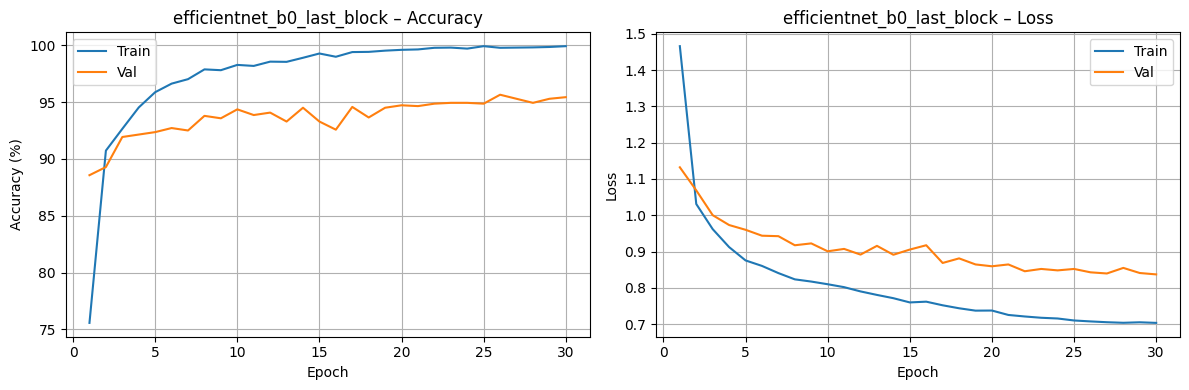

[Plot] Saved → ./output/efficientnet_b0_last_block_curves.png
[Plot] ./output/efficientnet_b0_last_block_grad_norm_heatmap.png
[Plot] ./output/efficientnet_b0_last_block_grad_norm_lines.png

  ── Strategy: Selective 20% ──
[Model] efficientnet_b0      | total params: 4,045,978 | trainable: 4,045,978 | frozen: False
  [unfreeze_20%]  budget=809,195  actually_unfrozen=809,114  (20.00%)
  [Selective 20%]  total=4,045,978  trainable=809,114  frozen=3,236,864  unfrozen=20.00%

  ── Training: efficientnet_b0_selective_20 (30 epochs) ──
    Epoch [01/30] train_loss=1.5031  train_acc=73.82%  val_loss=1.1714  val_acc=87.42%
    Epoch [02/30] train_loss=1.0271  train_acc=90.54%  val_loss=1.0559  val_acc=91.57%
    Epoch [03/30] train_loss=0.9155  train_acc=94.97%  val_loss=0.9942  val_acc=91.78%
    Epoch [04/30] train_loss=0.8760  train_acc=96.22%  val_loss=0.9847  val_acc=92.35%
    Epoch [05/30] train_loss=0.8544  train_acc=96.54%  val_loss=0.9519  val_acc=93.78%
    Epoch [06/30] train_loss=

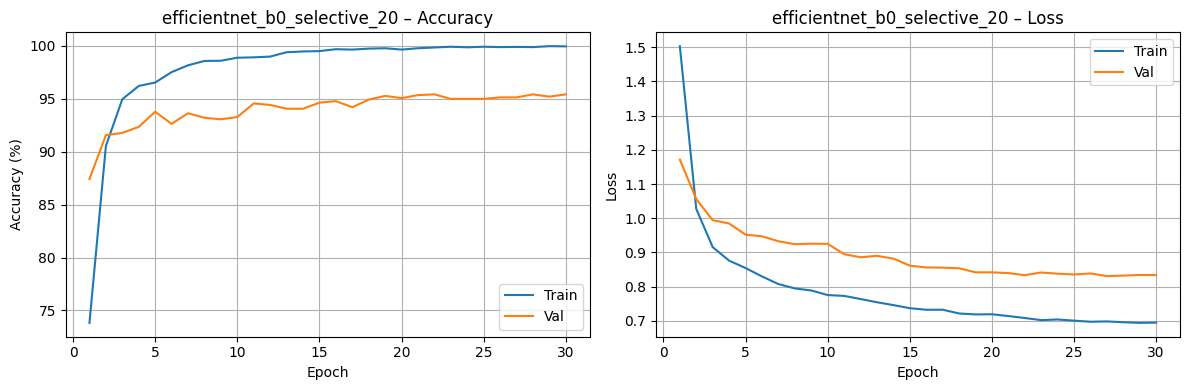

[Plot] Saved → ./output/efficientnet_b0_selective_20_curves.png
[Plot] ./output/efficientnet_b0_selective_20_grad_norm_heatmap.png
[Plot] ./output/efficientnet_b0_selective_20_grad_norm_lines.png

  ── Strategy: Full Fine-Tune ──
[Model] efficientnet_b0      | total params: 4,045,978 | trainable: 4,045,978 | frozen: False
  [Full Fine-Tune]  total=4,045,978  trainable=4,045,978  frozen=0  unfrozen=100.00%

  ── Training: efficientnet_b0_full_ft (30 epochs) ──
    Epoch [01/30] train_loss=1.8497  train_acc=61.00%  val_loss=1.1231  val_acc=88.21%
    Epoch [02/30] train_loss=1.0547  train_acc=89.47%  val_loss=1.0083  val_acc=91.07%
    Epoch [03/30] train_loss=0.9253  train_acc=94.32%  val_loss=0.9573  val_acc=92.64%
    Epoch [04/30] train_loss=0.8711  train_acc=96.11%  val_loss=0.9163  val_acc=93.28%
    Epoch [05/30] train_loss=0.8294  train_acc=97.26%  val_loss=0.8995  val_acc=93.85%
    Epoch [06/30] train_loss=0.8002  train_acc=98.28%  val_loss=0.8936  val_acc=93.92%
    Epoch [07/

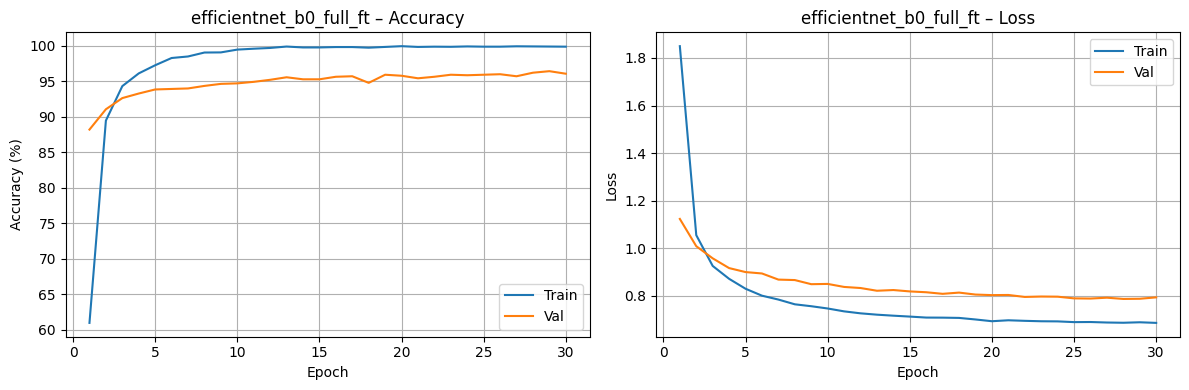

[Plot] Saved → ./output/efficientnet_b0_full_ft_curves.png
[Plot] ./output/efficientnet_b0_full_ft_grad_norm_heatmap.png
[Plot] ./output/efficientnet_b0_full_ft_grad_norm_lines.png


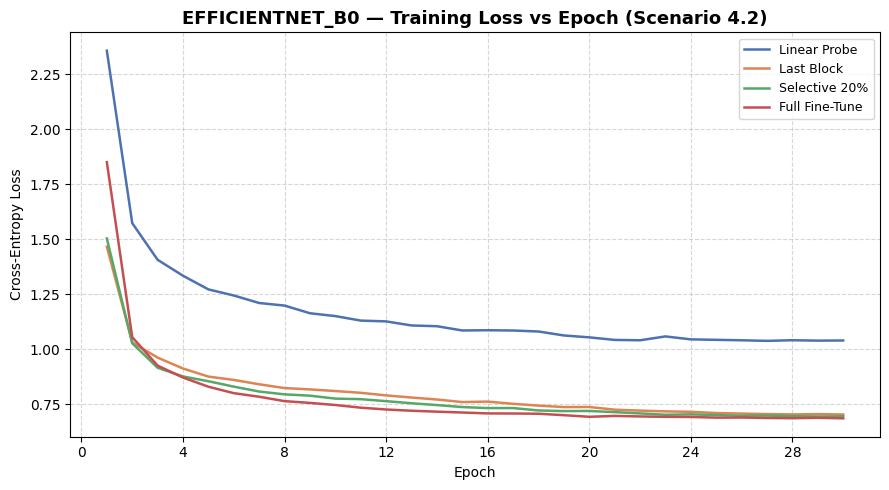

[Plot] ./output/efficientnet_b0_4_2_convergence.png

═════════════════════════════════════════════════════════════════
  MODEL: CONVNEXT_TINY
═════════════════════════════════════════════════════════════════

  ── Strategy: Linear Probe ──
[Model] convnext_tiny        | total params: 27,843,198 | trainable: 27,843,198 | frozen: False
  [Linear Probe]  total=27,843,198  trainable=23,070  frozen=27,820,128  unfrozen=0.08%

  ── Training: convnext_tiny_linear_probe (30 epochs) ──
    Epoch [01/30] train_loss=1.3284  train_acc=78.64%  val_loss=1.0377  val_acc=89.92%
    Epoch [02/30] train_loss=0.9815  train_acc=91.99%  val_loss=0.9931  val_acc=91.28%
    Epoch [03/30] train_loss=0.9280  train_acc=94.57%  val_loss=0.9929  val_acc=92.35%
    Epoch [04/30] train_loss=0.9029  train_acc=95.38%  val_loss=0.9843  val_acc=91.42%
    Epoch [05/30] train_loss=0.8825  train_acc=96.13%  val_loss=0.9848  val_acc=91.78%
    Epoch [06/30] train_loss=0.8721  train_acc=96.33%  val_loss=0.9744  val_acc=91.

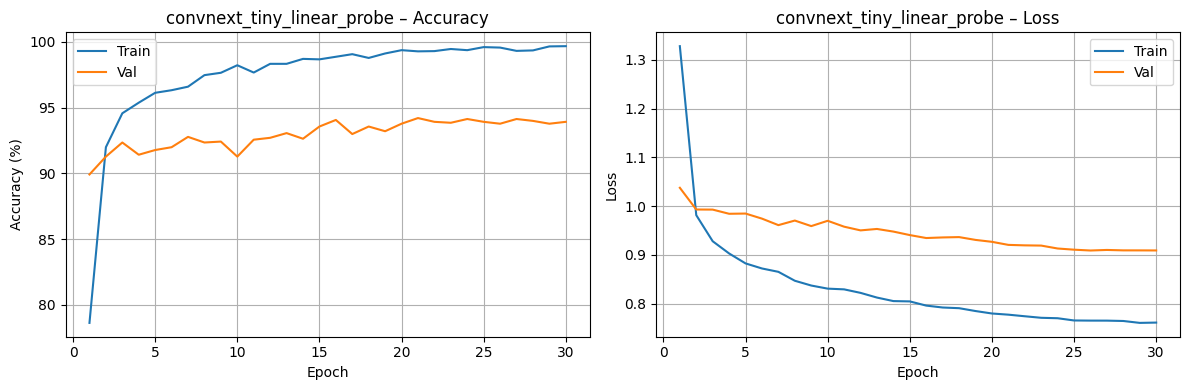

[Plot] Saved → ./output/convnext_tiny_linear_probe_curves.png
[Plot] ./output/convnext_tiny_linear_probe_grad_norm_heatmap.png
[Plot] ./output/convnext_tiny_linear_probe_grad_norm_lines.png

  ── Strategy: Last Block ──
[Model] convnext_tiny        | total params: 27,843,198 | trainable: 27,843,198 | frozen: False
  [Last Block]  total=27,843,198  trainable=15,493,662  frozen=12,349,536  unfrozen=55.65%

  ── Training: convnext_tiny_last_block (30 epochs) ──
    Epoch [01/30] train_loss=1.2868  train_acc=79.23%  val_loss=0.8644  val_acc=93.85%
    Epoch [02/30] train_loss=0.8402  train_acc=93.84%  val_loss=0.9226  val_acc=90.56%
    Epoch [03/30] train_loss=0.7961  train_acc=95.00%  val_loss=0.8224  val_acc=93.50%
    Epoch [04/30] train_loss=0.7478  train_acc=96.74%  val_loss=0.8739  val_acc=92.57%
    Epoch [05/30] train_loss=0.7624  train_acc=96.28%  val_loss=0.8544  val_acc=93.42%
    Epoch [06/30] train_loss=0.7451  train_acc=96.81%  val_loss=0.8355  val_acc=93.57%
    Epoch [07/3

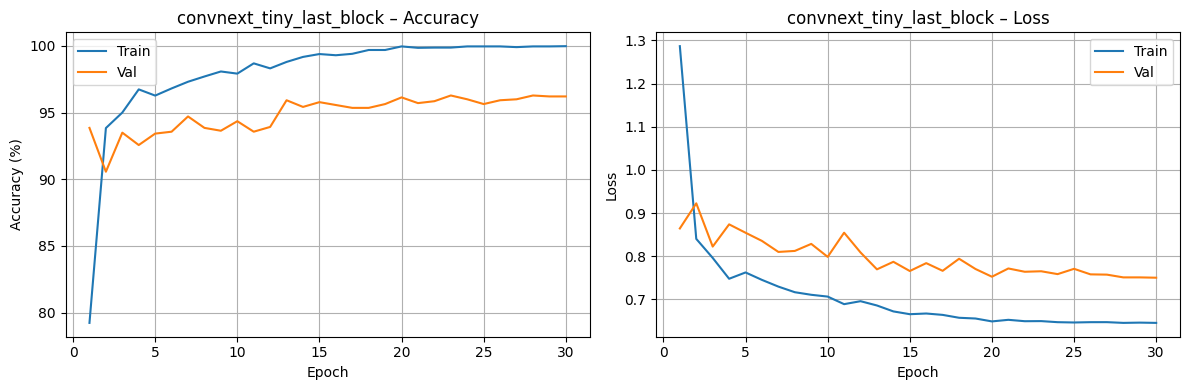

[Plot] Saved → ./output/convnext_tiny_last_block_curves.png
[Plot] ./output/convnext_tiny_last_block_grad_norm_heatmap.png
[Plot] ./output/convnext_tiny_last_block_grad_norm_lines.png

  ── Strategy: Selective 20% ──
[Model] convnext_tiny        | total params: 27,843,198 | trainable: 27,843,198 | frozen: False
  [unfreeze_20%]  budget=5,568,639  actually_unfrozen=5,568,606  (20.00%)
  [Selective 20%]  total=27,843,198  trainable=5,568,606  frozen=22,274,592  unfrozen=20.00%

  ── Training: convnext_tiny_selective_20 (30 epochs) ──
    Epoch [01/30] train_loss=1.2671  train_acc=80.00%  val_loss=0.9954  val_acc=88.63%
    Epoch [02/30] train_loss=0.8632  train_acc=93.36%  val_loss=0.9146  val_acc=90.92%
    Epoch [03/30] train_loss=0.7953  train_acc=95.34%  val_loss=0.8935  val_acc=91.71%
    Epoch [04/30] train_loss=0.7704  train_acc=96.13%  val_loss=0.9633  val_acc=89.42%
    Epoch [05/30] train_loss=0.7706  train_acc=96.35%  val_loss=0.8496  val_acc=92.78%
    Epoch [06/30] train_los

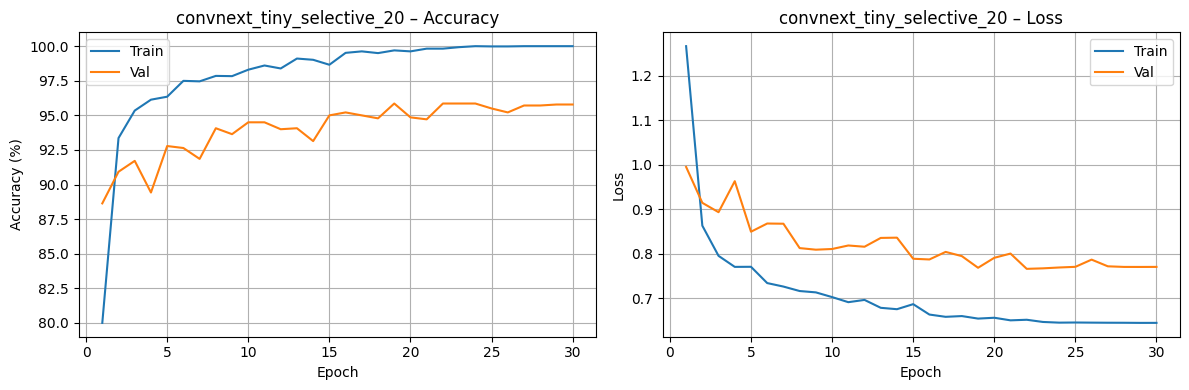

[Plot] Saved → ./output/convnext_tiny_selective_20_curves.png
[Plot] ./output/convnext_tiny_selective_20_grad_norm_heatmap.png
[Plot] ./output/convnext_tiny_selective_20_grad_norm_lines.png

  ── Strategy: Full Fine-Tune ──
[Model] convnext_tiny        | total params: 27,843,198 | trainable: 27,843,198 | frozen: False
  [Full Fine-Tune]  total=27,843,198  trainable=27,843,198  frozen=0  unfrozen=100.00%

  ── Training: convnext_tiny_full_ft (30 epochs) ──
    Epoch [01/30] train_loss=1.2897  train_acc=78.40%  val_loss=0.8726  val_acc=92.57%
    Epoch [02/30] train_loss=0.8177  train_acc=94.50%  val_loss=0.8918  val_acc=92.21%
    Epoch [03/30] train_loss=0.7525  train_acc=96.67%  val_loss=0.8193  val_acc=93.78%
    Epoch [04/30] train_loss=0.7337  train_acc=97.28%  val_loss=0.7821  val_acc=94.92%
    Epoch [05/30] train_loss=0.7271  train_acc=97.37%  val_loss=0.8770  val_acc=92.07%
    Epoch [06/30] train_loss=0.7470  train_acc=96.47%  val_loss=0.8678  val_acc=92.28%
    Epoch [07/30] 

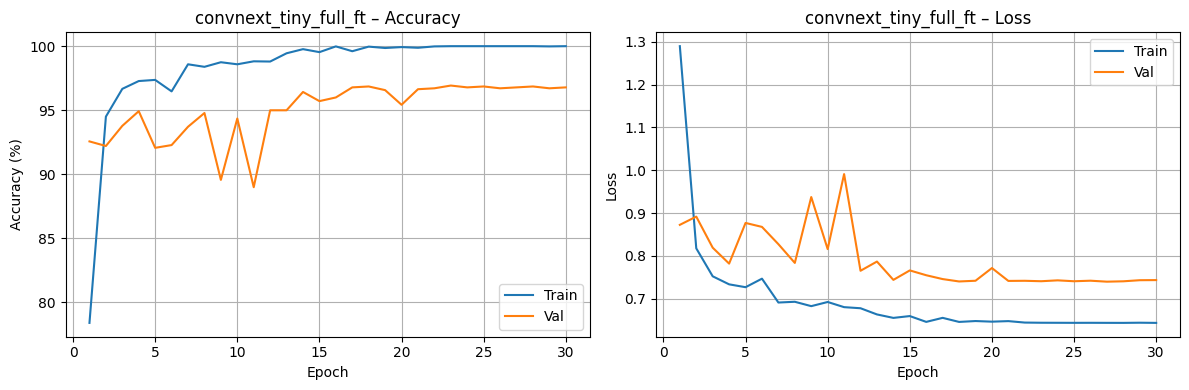

[Plot] Saved → ./output/convnext_tiny_full_ft_curves.png
[Plot] ./output/convnext_tiny_full_ft_grad_norm_heatmap.png
[Plot] ./output/convnext_tiny_full_ft_grad_norm_lines.png


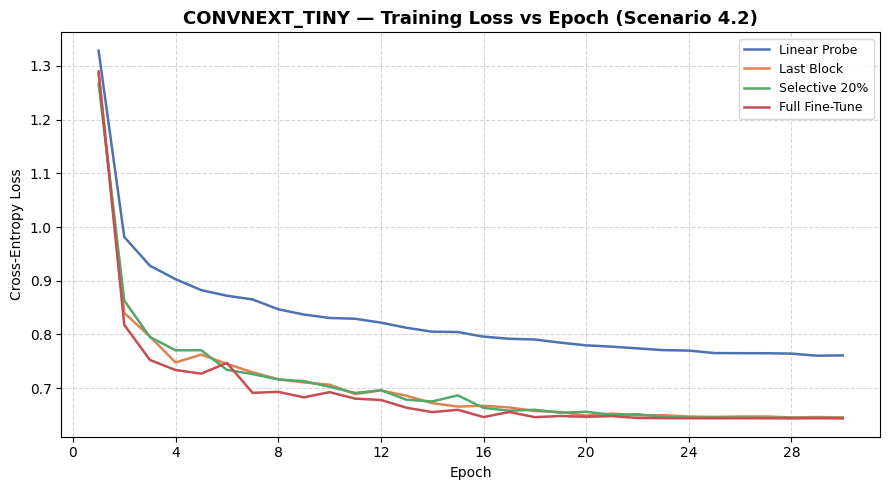

[Plot] ./output/convnext_tiny_4_2_convergence.png


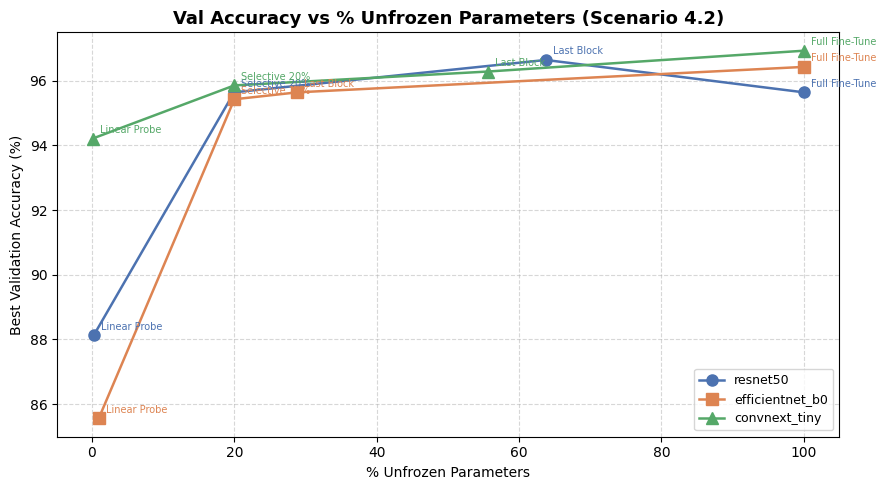

[Plot] ./output/4_2_accuracy_vs_unfrozen.png


═══════════════════════════════════════════════════════════════════════════
  SCENARIO 4.2 SUMMARY
═══════════════════════════════════════════════════════════════════════════
  Model                Strategy              %Unfrozen    BestValAcc
  ──────────────────────────────────────────────────────────────────
  resnet50             Linear Probe              0.26%        88.13%
  resnet50             Last Block               63.75%        96.64%
  resnet50             Selective 20%            19.97%        95.64%
  resnet50             Full Fine-Tune          100.00%        95.64%
  efficientnet_b0      Linear Probe              0.95%        85.56%
  efficientnet_b0      Last Block               28.86%        95.64%
  efficientnet_b0      Selective 20%            20.00%        95.43%
  efficientnet_b0      Full Fine-Tune          100.00%        96.43%
  convnext_tiny        Linear Probe              0.08%        94.21%
  convnext_tiny    

In [ ]:
train_loader, val_loader, class_names = build_dataloaders(
    data_root   = CONFIG["data_root"],
    image_size  = CONFIG["image_size"],
    batch_size  = CONFIG["batch_size"],
    train_split = CONFIG["train_split"],
    num_workers = CONFIG["num_workers"],
    fraction    = 1.0, 
    seed        = CONFIG["seed"]
)

print("Starting Scenario 4.2...")
results_4_2 = run_scenario_4_2(train_loader, val_loader)
print("Scenario 4.2 Complete! Check the Kaggle 'Output' directory for your plots.")

In [ ]:
"""
GNR638 Assignment-2 | Scenario 4.5 — Layer-Wise Feature Probing
================================================================
ADD-ON SCRIPT — paste and run at the bottom of your notebook.

Assumes the following already exist in global scope:
    • load_model(model_key, num_classes, pretrained)  → nn.Module
    • register_feature_hook(model, layer_name)        → cache dict
    • get_probe_layers(model_key)                     → {"early","middle","final"}
    • build_dataloaders(...)                          → train_loader, val_loader, class_names
    • MODEL_NAMES   dict  {model_key: timm_name}
    • CONFIG        dict  (num_classes, image_size, batch_size, …)

What this script produces


─────
  Per model × layer:
    • Extracted feature matrix  (N × D)
    • Linear probe validation accuracy
    • Feature-norm statistics   (mean, std, min, max of L2 row-norms)

  Plots (saved to CONFIG["output_dir"]):
    1.  scenario_4_5_probe_accuracy.png   — val acc vs depth, 3 model lines
    2.  scenario_4_5_feature_norms.png    — feature-norm bar chart per layer
    3.  scenario_4_5_pca_{model}_{layer}.png — PCA 2-D scatter (30 cls × 30 samp)
"""

import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset

import matplotlib
matplotlib.use("Agg")         
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# 0.CONSTANTS

DEPTH_ORDER  = ["early", "middle", "final"]       # canonical x-axis order
DEPTH_LABELS = {"early": "Early", "middle": "Middle", "final": "Final"}

MODEL_COLORS = {
    "resnet50":        "#4C72B0",
    "efficientnet_b0": "#DD8452",
    "convnext_tiny":   "#55A868",
}
MODEL_MARKERS = {
    "resnet50":        "o",
    "efficientnet_b0": "s",
    "convnext_tiny":   "^",
}

# Fixed subset used for PCA visualisation: 30 classes × 30 samples each
PCA_SAMPLES_PER_CLASS = 30

# 1.  FIXED SUBSET BUILDER  (same samples across all models / layers)
def build_fixed_pca_subset(
    full_dataset,         
    num_classes:  int = 30,
    samples_per_class: int = PCA_SAMPLES_PER_CLASS,
    seed: int = 42,
) -> Subset:
    rng = np.random.default_rng(seed)

    # Build a label → [index …] mapping
    label_to_indices: dict[int, list[int]] = {c: [] for c in range(num_classes)}
    for idx in range(len(full_dataset)):
        _, lbl = full_dataset[idx]
        lbl = int(lbl)
        if lbl in label_to_indices:
            label_to_indices[lbl].append(idx)

    selected = []
    for cls_idx in range(num_classes):
        pool = label_to_indices[cls_idx]
        k    = min(samples_per_class, len(pool))
        chosen = rng.choice(pool, size=k, replace=False).tolist()
        selected.extend(chosen)

    return Subset(full_dataset, selected)

# 2.  FEATURE EXTRACTION


def _global_avg_pool(tensor: torch.Tensor) -> torch.Tensor:
    if tensor.dim() == 4:                  # (B, C, H, W)
        return tensor.mean(dim=[2, 3])
    elif tensor.dim() == 3:                # (B, L, C)  or  (B, C, L)
        return tensor.mean(dim=1)
    return tensor                          # already (B, D)


@torch.no_grad()
def extract_layer_features(
    model:      nn.Module,
    loader:     DataLoader,
    layer_name: str,
    device:     str = "cpu",
) -> tuple[np.ndarray, np.ndarray]:
    model = model.to(device)
    model.eval()

    cache = register_feature_hook(model, layer_name)  

    all_features: list[np.ndarray] = []
    all_labels:   list[np.ndarray] = []

    for images, lbls in loader:
        images = images.to(device)
        _      = model(images)            # forward pass populates cache

        feat = cache["features"]          # tensor on device, arbitrary shape
        feat = _global_avg_pool(feat)     # → (B, D)
        all_features.append(feat.cpu().numpy())
        all_labels.append(lbls.numpy())

    features = np.vstack(all_features)    # (N, D)
    labels   = np.concatenate(all_labels) # (N,)
    return features, labels


# 3.  LINEAR PROBE CLASSIFIER

def train_linear_probe_on_features(
    train_features: np.ndarray,
    train_labels:   np.ndarray,
    val_features:   np.ndarray,
    val_labels:     np.ndarray,
    num_classes:    int = 30,
    max_iter:       int = 1000,
    seed:           int = 42,
) -> tuple[float, object]:
   
    probe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(
            #multi_class="multinomial",
            solver="lbfgs",
            max_iter=max_iter,
            C=1.0,
            random_state=seed,
            n_jobs=-1,
        )),
    ])

    t0 = time.time()
    probe.fit(train_features, train_labels)
    elapsed = time.time() - t0

    preds        = probe.predict(val_features)
    val_accuracy = 100.0 * (preds == val_labels).mean()

    print(f"      Probe fit: {elapsed:.1f}s  |  val_acc = {val_accuracy:.2f}%")
    return val_accuracy, probe



# 4.  FEATURE-NORM STATISTICS
def compute_feature_norms(features: np.ndarray) -> dict:
   
    norms = np.linalg.norm(features, axis=1)   # (N,)
    return {
        "mean":   float(norms.mean()),
        "std":    float(norms.std()),
        "min":    float(norms.min()),
        "max":    float(norms.max()),
        "median": float(np.median(norms)),
    }

# 5.  PCA 2-D SCATTER  (fixed 30 × 30 subset)

def plot_pca_layer(
    features:    np.ndarray,
    labels:      np.ndarray,
    class_names: list,
    title:       str,
    save_path:   str,
):
    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(features)
    var_ex = pca.explained_variance_ratio_.sum()

    n_cls  = len(class_names)
    cmap   = plt.cm.get_cmap("tab20", n_cls)

    fig, ax = plt.subplots(figsize=(9, 7))
    for cls_idx in range(n_cls):
        mask = labels == cls_idx
        if not mask.any():
            continue
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=cmap(cls_idx), s=18, alpha=0.75,
                   label=class_names[cls_idx])

    ax.set_title(f"{title}\nPCA  (var explained: {var_ex:.1%})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.legend(
        bbox_to_anchor=(1.02, 1), loc="upper left",
        fontsize=5, markerscale=1.8, ncol=2,
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"    [PCA plot] saved → {save_path}")


# 6.  COMPARATIVE PLOTS  

def plot_probe_accuracy_vs_depth(
    probe_results: dict,      # {model_key: {depth: val_acc}}
    save_dir:      str = ".",
):
    
    fig, ax = plt.subplots(figsize=(8, 5))

    x_positions = list(range(len(DEPTH_ORDER)))   # 0, 1, 2

    for model_key, depth_acc in probe_results.items():
        ys = [depth_acc.get(d, np.nan) for d in DEPTH_ORDER]
        ax.plot(
            x_positions, ys,
            color=MODEL_COLORS[model_key],
            marker=MODEL_MARKERS[model_key],
            linewidth=2.2,
            markersize=9,
            label=model_key,
            zorder=3,
        )
        # Annotate each point with its accuracy value
        for xi, yi in zip(x_positions, ys):
            if not np.isnan(yi):
                ax.annotate(f"{yi:.1f}%",
                            xy=(xi, yi),
                            xytext=(0, 8),
                            textcoords="offset points",
                            ha="center", fontsize=8,
                            color=MODEL_COLORS[model_key])

    ax.set_xticks(x_positions)
    ax.set_xticklabels([DEPTH_LABELS[d] for d in DEPTH_ORDER], fontsize=11)
    ax.set_xlabel("Layer Depth", fontsize=12)
    ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
    ax.set_title("Scenario 4.5 — Linear Probe Accuracy vs Layer Depth",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.45)
    ax.set_ylim(bottom=max(0, min(
        v for dct in probe_results.values()
        for v in dct.values() if not np.isnan(v)
    ) - 10))

    plt.tight_layout()
    path = os.path.join(save_dir, "scenario_4_5_probe_accuracy.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"\n[Plot] Probe accuracy saved → {path}")


def plot_feature_norm_bars(
    norm_results: dict,       # {model_key: {depth: norm_stats_dict}}
    save_dir:     str = ".",
):
    """
    Grouped bar chart: mean feature L2 norm per (model, layer depth).

    Error bars show ± 1 standard deviation across samples, giving a sense
    of within-layer norm variance (low variance → more uniform representations).
    """
    n_depths = len(DEPTH_ORDER)
    n_models = len(norm_results)
    bar_width = 0.22
    x_base    = np.arange(n_depths)

    fig, ax = plt.subplots(figsize=(9, 5))

    for i, (model_key, depth_norms) in enumerate(norm_results.items()):
        means = [depth_norms.get(d, {}).get("mean", 0) for d in DEPTH_ORDER]
        stds  = [depth_norms.get(d, {}).get("std",  0) for d in DEPTH_ORDER]
        offset = (i - n_models / 2 + 0.5) * bar_width
        bars = ax.bar(
            x_base + offset, means, bar_width,
            yerr=stds, capsize=4,
            color=MODEL_COLORS[model_key],
            label=model_key, alpha=0.85,
        )

    ax.set_xticks(x_base)
    ax.set_xticklabels([DEPTH_LABELS[d] for d in DEPTH_ORDER], fontsize=11)
    ax.set_xlabel("Layer Depth", fontsize=12)
    ax.set_ylabel("Mean Feature L2 Norm (± std)", fontsize=12)
    ax.set_title("Scenario 4.5 — Feature Norm Statistics Across Depth",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, axis="y", linestyle="--", alpha=0.45)

    plt.tight_layout()
    path = os.path.join(save_dir, "scenario_4_5_feature_norms.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"[Plot] Feature norms saved → {path}")


# 7.  ORCHESTRATOR

def run_scenario_4_5(cfg: dict = None):
  
    if cfg is None:
        cfg = CONFIG   

    device      = cfg["device"]
    output_dir  = cfg["output_dir"]
    num_classes = cfg["num_classes"]
    seed        = cfg.get("seed", 42)

    os.makedirs(output_dir, exist_ok=True)

    # Build train / val loaders (100% data, full val set) 
    print("\n[4.5] Building dataloaders …")
    train_loader, val_loader, class_names = build_dataloaders( 
        data_root   = cfg["data_root"],
        image_size  = cfg["image_size"],
        batch_size  = cfg["batch_size"],
        train_split = cfg["train_split"],
        num_workers = cfg["num_workers"],
        fraction    = 1.0,
        seed        = seed,
    )

    # Build fixed PCA subset loader
    
    # We re-create a raw ImageFolder so we can apply the standard val transform
    # and then sub-sample the fixed 30 × 30 indices.
    from torchvision import datasets, transforms

    val_tf = transforms.Compose([
        transforms.Resize(int(cfg["image_size"] * 1.14)),
        transforms.CenterCrop(cfg["image_size"]),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    raw_ds      = datasets.ImageFolder(root=cfg["data_root"], transform=val_tf)
    pca_subset  = build_fixed_pca_subset(
        raw_ds, num_classes=num_classes,
        samples_per_class=PCA_SAMPLES_PER_CLASS, seed=seed)
    pca_loader  = DataLoader(pca_subset, batch_size=cfg["batch_size"],
                             shuffle=False, num_workers=cfg["num_workers"],
                             pin_memory=True)
    print(f"  Fixed PCA subset: {len(pca_subset)} images  "
          f"({num_classes} classes × {PCA_SAMPLES_PER_CLASS} samples)")

    # Accumulators for cross-model plots
    probe_results: dict[str, dict[str, float]] = {} 
    norm_results:  dict[str, dict[str, dict]]  = {}
    all_results:   dict[str, dict]             = {}

    
    for model_key in MODEL_NAMES.keys():  
        print(f"\n{'═'*65}")
        print(f"  MODEL: {model_key.upper()}")
        print(f"{'═'*65}")

        # Load fully pretrained model (frozen — probing ImageNet representations)
        model = load_model(   
            model_key, num_classes=num_classes, pretrained=True)
        for p in model.parameters():
            p.requires_grad = False
        model = model.to(device)
        model.eval()

        probe_results[model_key] = {}
        norm_results[model_key]  = {}
        all_results[model_key]   = {}

        # Resolve layer names for this architecture
        layers: dict[str, str] = get_probe_layers(model_key)   # noqa: F821
        print(f"  Probe layers: {layers}")

        # Extract train features once per model (all layers share one pass) ─
        # We extract per-layer rather than in one pass because different hooks
        # would be active simultaneously, which can cause memory issues for
        # large models. Sequential extraction is safer and negligibly slower.

        for depth in DEPTH_ORDER:
            layer_name = layers[depth]
            print(f"\n  ── Depth: {DEPTH_LABELS[depth]}  (layer: {layer_name}) ──")

            #Extract features
            print("    Extracting train features …")
            train_feats, train_lbls = extract_layer_features(
                model, train_loader, layer_name, device)

            print("    Extracting val features …")
            val_feats, val_lbls = extract_layer_features(
                model, val_loader, layer_name, device)

            print(f"    Feature shape: train={train_feats.shape}  "
                  f"val={val_feats.shape}")

            # Feature norm statistics
            t_norms = compute_feature_norms(train_feats)
            v_norms = compute_feature_norms(val_feats)
            norm_results[model_key][depth] = v_norms
            print(f"    Val feature norms — "
                  f"mean={v_norms['mean']:.3f}  std={v_norms['std']:.3f}  "
                  f"min={v_norms['min']:.3f}  max={v_norms['max']:.3f}")

            # Linear probe
            print("    Training linear probe …")
            val_acc, fitted_probe = train_linear_probe_on_features(
                train_feats, train_lbls,
                val_feats,   val_lbls,
                num_classes=num_classes,
                seed=seed,
            )
            probe_results[model_key][depth] = val_acc

            #PCA scatter on the fixed subset
            print("    Extracting PCA subset features …")
            pca_feats, pca_lbls = extract_layer_features(
                model, pca_loader, layer_name, device)

            pca_title  = f"{model_key}  |  {DEPTH_LABELS[depth]} layer"
            pca_fname  = (f"scenario_4_5_pca_{model_key}_{depth}.png")
            pca_path   = os.path.join(output_dir, pca_fname)
            plot_pca_layer(pca_feats, pca_lbls, class_names,
                           pca_title, pca_path)

            all_results[model_key][depth] = {
                "val_acc":         val_acc,
                "norm_stats_val":  v_norms,
                "norm_stats_train": t_norms,
                "probe":           fitted_probe,
                "layer_name":      layer_name,
            }

    print("\n\n[4.5] Generating summary plots …")
    plot_probe_accuracy_vs_depth(probe_results, save_dir=output_dir)
    plot_feature_norm_bars(norm_results,         save_dir=output_dir)

    print("\n\n" + "═" * 70)
    print("  SCENARIO 4.5  SUMMARY — Linear Probe Validation Accuracy (%)")
    print("═" * 70)
    header = f"  {'Model':<22} {'Early':>10} {'Middle':>10} {'Final':>10}"
    print(header)
    print("  " + "─" * 56)
    for mk in MODEL_NAMES.keys():   # noqa: F821
        row = probe_results.get(mk, {})
        e = row.get("early",  float("nan"))
        m = row.get("middle", float("nan"))
        f = row.get("final",  float("nan"))
        print(f"  {mk:<22} {e:>9.2f}%  {m:>9.2f}%  {f:>9.2f}%")
    print("═" * 70)

    print("\n\n  FEATURE L2 NORM STATISTICS (val split, mean ± std)")
    print("═" * 70)
    print(f"  {'Model':<22} {'Depth':<10} {'Mean':>8} {'Std':>8} "
          f"{'Min':>8} {'Max':>8}")
    print("  " + "─" * 56)
    for mk in MODEL_NAMES.keys():   # noqa: F821
        for depth in DEPTH_ORDER:
            ns = norm_results.get(mk, {}).get(depth, {})
            print(f"  {mk:<22} {DEPTH_LABELS[depth]:<10} "
                  f"{ns.get('mean', 0):>8.3f} "
                  f"{ns.get('std',  0):>8.3f} "
                  f"{ns.get('min',  0):>8.3f} "
                  f"{ns.get('max',  0):>8.3f}")
    print("═" * 70 + "\n")

    return all_results


# 8.  ENTRY POINT
if __name__ == "__main__":
    results_4_5 = run_scenario_4_5(cfg=CONFIG)


[4.5] Building dataloaders …
[Dataset] Classes      : 30
[Dataset] Total images : 6993
[Dataset] Train        : 5594  (fraction=100%)
[Dataset] Val          : 1399
  Fixed PCA subset: 900 images  (30 classes × 30 samples)

═════════════════════════════════════════════════════════════════
  MODEL: RESNET50
═════════════════════════════════════════════════════════════════
[Model] resnet50             | total params: 23,569,502 | trainable: 23,569,502 | frozen: False
  Probe layers: {'early': 'layer1', 'middle': 'layer3', 'final': 'layer4'}

  ── Depth: Early  (layer: layer1) ──
    Extracting train features …
    Extracting val features …
    Feature shape: train=(5584, 256)  val=(1399, 256)
    Val feature norms — mean=18.563  std=0.510  min=17.629  max=20.998
    Training linear probe …
      Probe fit: 21.8s  |  val_acc = 83.20%
    Extracting PCA subset features …
    [PCA plot] saved → ./output/scenario_4_5_pca_resnet50_early.png

  ── Depth: Middle  (layer: layer3) ──
    Extracti